In [35]:
# Recarga `erp` cuando cambia el codigo del paquete, sin reiniciar el kernel.
# Sin esto, una celda nueva que usa algo agregado al paquete (p. ej.
# `IMUDecoder.to_raw`) falla con AttributeError contra la version vieja.
%load_ext autoreload
%autoreload 2

import mujoco as mj
import mujoco.viewer
from pathlib import Path
import time
import numpy as np
import matplotlib.pyplot as plt
import mediapy as media

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
REPO_NAME = "preERP"

XML_RELATIVE_PATH = Path("mechanical/mujoco_assets/MyPalletizer260/MyPalletizer260.xml")

def find_repo_root(start: Path, name: str = REPO_NAME) -> Path:
    """Sube desde `start` hasta el ancestro llamado `name`.

    `start` incluido: si ya estas parado en el repo, no sube nada. Si el
    nombre no aparece, cae a la busqueda por marcador (pyproject.toml), que
    es lo que hace que esto siga funcionando si renombras la carpeta.
    """
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if candidate.name.lower() == name.lower():
            return candidate
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError(
        f"No se encontro la carpeta '{name}' ni un pyproject.toml subiendo "
        f"desde {start}. Corre el notebook dentro del repo, o fija repo_root a mano."
    )


repo_root = find_repo_root(Path.cwd())
model_path = (repo_root / XML_RELATIVE_PATH).resolve()

if not model_path.is_file():
    raise FileNotFoundError(
        f"Repo root OK ({repo_root}), pero no existe {XML_RELATIVE_PATH} adentro."
        f"Buscado en: {model_path}"
    )

print(f"repo root:  {repo_root}")
print(f"Cargando modelo MuJoCo desde: {model_path}")

model = mj.MjModel.from_xml_path(str(model_path))
data = mj.MjData(model)
mj.mj_resetDataKeyframe(model, data, model.key("home").id)
dt = model.opt.timestep
print(f"Modelo cargado OK -> bodies: {model.nbody}, joints: {model.njnt}, "
      f"geoms: {model.ngeom}, actuadores: {model.nu}")
for j in range(model.njnt):
    print("  joint", j, mj.mj_id2name(model, mj.mjtObj.mjOBJ_JOINT, j))

print("qpos0 =", model.qpos0,"\n qpos =", data.qpos)

repo root:  C:\Users\nicoa\Desktop\Universidad\ERP\preERP
Cargando modelo MuJoCo desde: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\mechanical\mujoco_assets\MyPalletizer260\MyPalletizer260.xml
Modelo cargado OK -> bodies: 6, joints: 4, geoms: 26, actuadores: 3
  joint 0 rot
  joint 1 link1
  joint 2 link2
  joint 3 act
qpos0 = [ 1.57   -3.1415  1.57    1.57  ] 
 qpos = [0.     0.     0.     1.5693]


### Trajectory

periodo 3.000 s (w = 2.094 rad/s), 1500 muestras a 500 Hz
pico de velocidad por junta [deg/s]: [62.8 20.9 41.9]  (spec del brazo: 120)


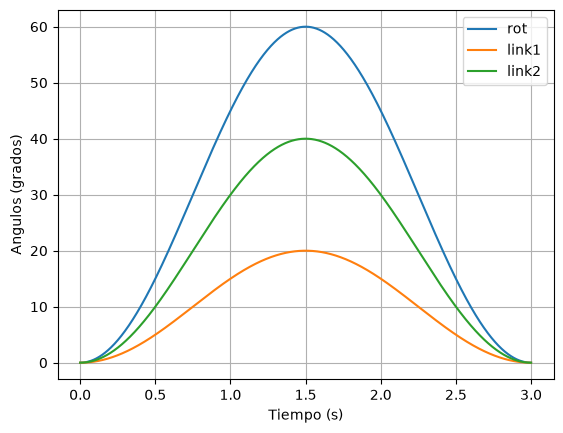

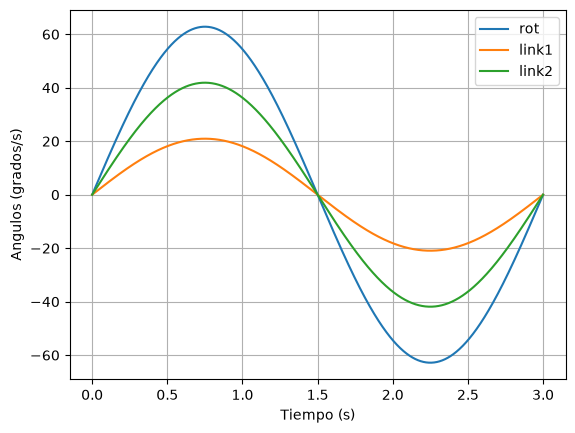

In [37]:
# --- 1. Trajectory Setup & Generation ---
#
# PERIODO_S es LA perilla de velocidad. Antes estaba implicita: `sin(i)` con
# `i` en segundos es w = 1 rad/s, y `sim_t = 2*pi` era justo un ciclo.
#
# NO CONFUNDIR CON `STREAM_RATE_HZ`. Esa es cada cuanto se manda un setpoint;
# subirla NO acelera el movimiento, solo manda mas puntos de la misma
# trayectoria. Si el brazo tiene que ir mas rapido, se acorta el periodo.
#
# La amplitud no cambia con el periodo, asi que los limites de POSICION siguen
# dando OK. Lo que escala es la VELOCIDAD, como A*w = 2*pi*A/PERIODO_S:
#
#   PERIODO_S   pico J1/J2/J3 [deg/s]   muestras/ciclo a 25 Hz   RMS J1 MuJoCo
#     6.283          30 / 10 / 20               157                 5.97 deg
#     4.0            47 / 16 / 31               100                 8.93 deg
#     3.0            63 / 21 / 42                75                11.26 deg
#     2.0            94 / 31 / 63                50                14.89 deg
#     1.571         120 / 40 / 80                39                17.07 deg
#
# 1.571 s es el PISO DURO: ahi J1 toca los 120 deg/s de spec del brazo
# (2*pi*30/120). `check_trajectory` valida la velocidad y frena antes de eso.
#
# El costo de ir rapido no es el par: medido, los servos no pasan del 10% de su
# `forcerange` en ningun caso. Es el ATRASO. El RMS de J1 en MuJoCo se
# triplica, porque `rot_servo` tiene kp=1.62 contra kp=63.35 de link1; y los
# ~143 ms de retardo del brazo, que a 6.283 s son 8 deg de fase, a 2 s son 26.

PERIODO_S = 3                # segundos por ciclo. Antes: 2*np.pi = 6.283
w = 2 * np.pi / PERIODO_S       # rad/s

dt = model.opt.timestep
sim_t = PERIODO_S
n_samples = int(sim_t / dt)
t = np.linspace(0, sim_t, n_samples)

amplitudes = np.deg2rad(np.array([30, 10, 20]))

# Vectorizado y como arrays desde el arranque. Esta es la UNICA definicion de
# la trayectoria: la celda de abajo la regeneraba con la formula vieja, que es
# como un cambio de periodo aca quedaba silenciosamente pisado.
q_target = np.sin(w * t - np.pi / 2)[:, None] * amplitudes + amplitudes
qd_target = amplitudes * w * np.cos(w * t - np.pi / 2)[:, None]
#                        ^^^ regla de la cadena. Sin el factor w la velocidad
# queda mal por ese factor y el grafico no lo delata: sigue siendo un coseno
# de la forma correcta, solo que con la escala equivocada.

print(f"periodo {PERIODO_S:.3f} s (w = {w:.3f} rad/s), "
      f"{n_samples} muestras a {1 / dt:.0f} Hz")
print("pico de velocidad por junta [deg/s]:",
      np.round(np.rad2deg(amplitudes * w), 1), " (spec del brazo: 120)")

plt.figure()
plt.plot(t, np.rad2deg(q_target))
plt.grid()
plt.ylabel("Angulos (grados)")
plt.xlabel("Tiempo (s)")
plt.legend(["rot", "link1", "link2"])

plt.figure()
plt.plot(t, np.rad2deg(qd_target))
plt.grid()
plt.ylabel("Angulos (grados/s)")
plt.xlabel("Tiempo (s)")
plt.legend(["rot", "link1", "link2"])

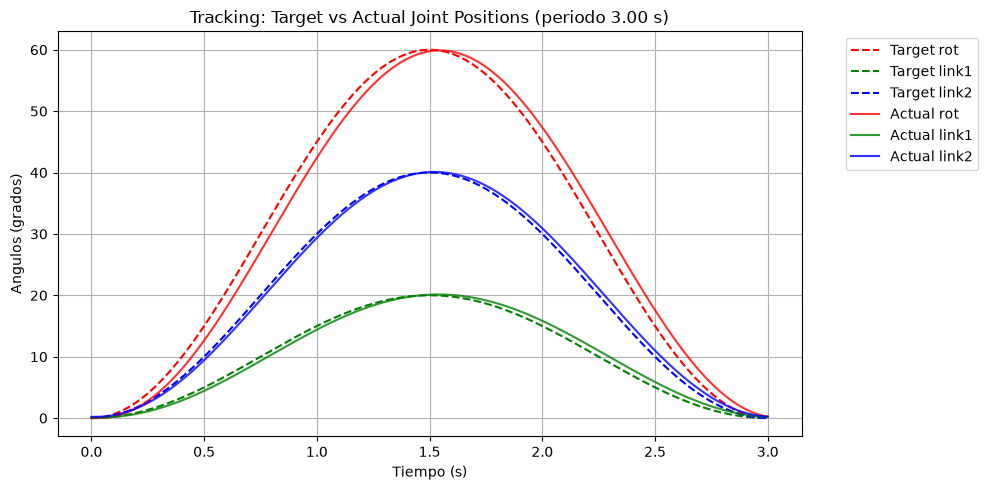

Showing video at 60 FPS...  (3.00 s por ciclo)


This browser does not support the video tag.


In [38]:
# --- 1. Simulacion y video de la MISMA trayectoria armada arriba ---
video_fps = 60                     # Target FPS for the output video

# Aca habia una SEGUNDA copia de la generacion de la trayectoria. La saque:
# regeneraba q_target con w = 1 rad/s fijo, asi que cambiar PERIODO_S en la
# celda de arriba no tenia ningun efecto -- esta celda lo pisaba con la version
# lenta y el video salia igual de lento, sin ninguna senal de por que.
# q_target / qd_target vienen de la celda anterior y son la unica definicion.

# --- 2. Simulation Setup ---
# Reset to 'home' keyframe initial position
mj.mj_resetDataKeyframe(model, data, model.key("home").id)

# Calentamiento: 0.2 s con la consigna fija en el primer punto, SIN loguear.
# En t = 0 la gravedad recien empieza a cargar los servos y hay un transitorio
# de ~10 ms que no es parte de la trayectoria. Despues se vuelve el reloj a 0
# para que `t` y `data.time` sigan alineados.
WARMUP_STEPS = 100
data.ctrl[:3] = q_target[0]
for _ in range(WARMUP_STEPS):
    mj.mj_step(model, data)
data.time = 0.0

renderer = mj.Renderer(model, height=480, width=640)

# --- 3. Run Simulation & Capture Frames ---
qpos_log = []
frames = []
sensor_log_sim = np.empty((n_samples, model.nsensordata), dtype=np.float64)
# Keep track of simulation time to render exactly at 60 FPS
last_render_time = data.time - 1.0 

for i in range(n_samples):
    # Set position target to actuators [rot_servo, link1_servo, link2_servo]
    data.ctrl[:3] = q_target[i]

    # Step simulation
    mj.mj_step(model, data)

    # sensordata se lee DESPUES del paso: mj_step calcula los sensores en el
    # estado de ANTES de integrar, asi que esta fila es la del instante i*dt.
    # Leerla antes del paso daba la fila 0 en ceros y todo un paso atrasado.
    sensor_log_sim[i] = data.sensordata
    
    # Log actual joint positions every simulation step (rot, link1, link2)
    qpos_log.append(data.qpos[:3].copy())
    
    # Render frame ONLY if 1/60th of a second has passed in simulation time
    if data.time - last_render_time >= 1.0 / video_fps:
        renderer.update_scene(data, camera="tracking_cam")
        frames.append(renderer.render())
        last_render_time = data.time

qpos_log = np.array(qpos_log)

# --- Post-Processing (Extract individual sensors after the loop) ---
link1_acc_history  = sensor_log_sim[:, 0:3]
link2_acc_history  = sensor_log_sim[:, 3:6]
link1_gyro_history = sensor_log_sim[:, 6:9]   # Primary signal for clock sync
link2_gyro_history = sensor_log_sim[:, 9:12]
efector_pos_history = sensor_log_sim[:, 12:15]

# --- 4. Plot Target vs Actual qpos ---
plt.figure(figsize=(10, 5))

# Target Joint Angles
plt.plot(t, np.rad2deg(q_target[:, 0]), 'r--', label="Target rot")
plt.plot(t, np.rad2deg(q_target[:, 1]), 'g--', label="Target link1")
plt.plot(t, np.rad2deg(q_target[:, 2]), 'b--', label="Target link2")

# Actual Joint Angles
plt.plot(t, np.rad2deg(qpos_log[:, 0]), 'r-', alpha=0.8, label="Actual rot")
plt.plot(t, np.rad2deg(qpos_log[:, 1]), 'g-', alpha=0.8, label="Actual link1")
plt.plot(t, np.rad2deg(qpos_log[:, 2]), 'b-', alpha=0.8, label="Actual link2")

plt.grid(True)
plt.ylabel("Angulos (grados)")
plt.xlabel("Tiempo (s)")
plt.title(f"Tracking: Target vs Actual Joint Positions (periodo {PERIODO_S:.2f} s)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- 5. Show Video via Mediapy ---
# El video sale en TIEMPO REAL: se captura un frame cada 1/60 s de tiempo de
# simulacion y se reproduce a 60 fps. Asi que lo que se ve en el video es la
# velocidad que va a tener el brazo -- ese es el punto de comparacion.
print(f"Showing video at {video_fps} FPS...  ({PERIODO_S:.2f} s por ciclo)")
media.show_video(frames, fps=video_fps)
renderer.close()

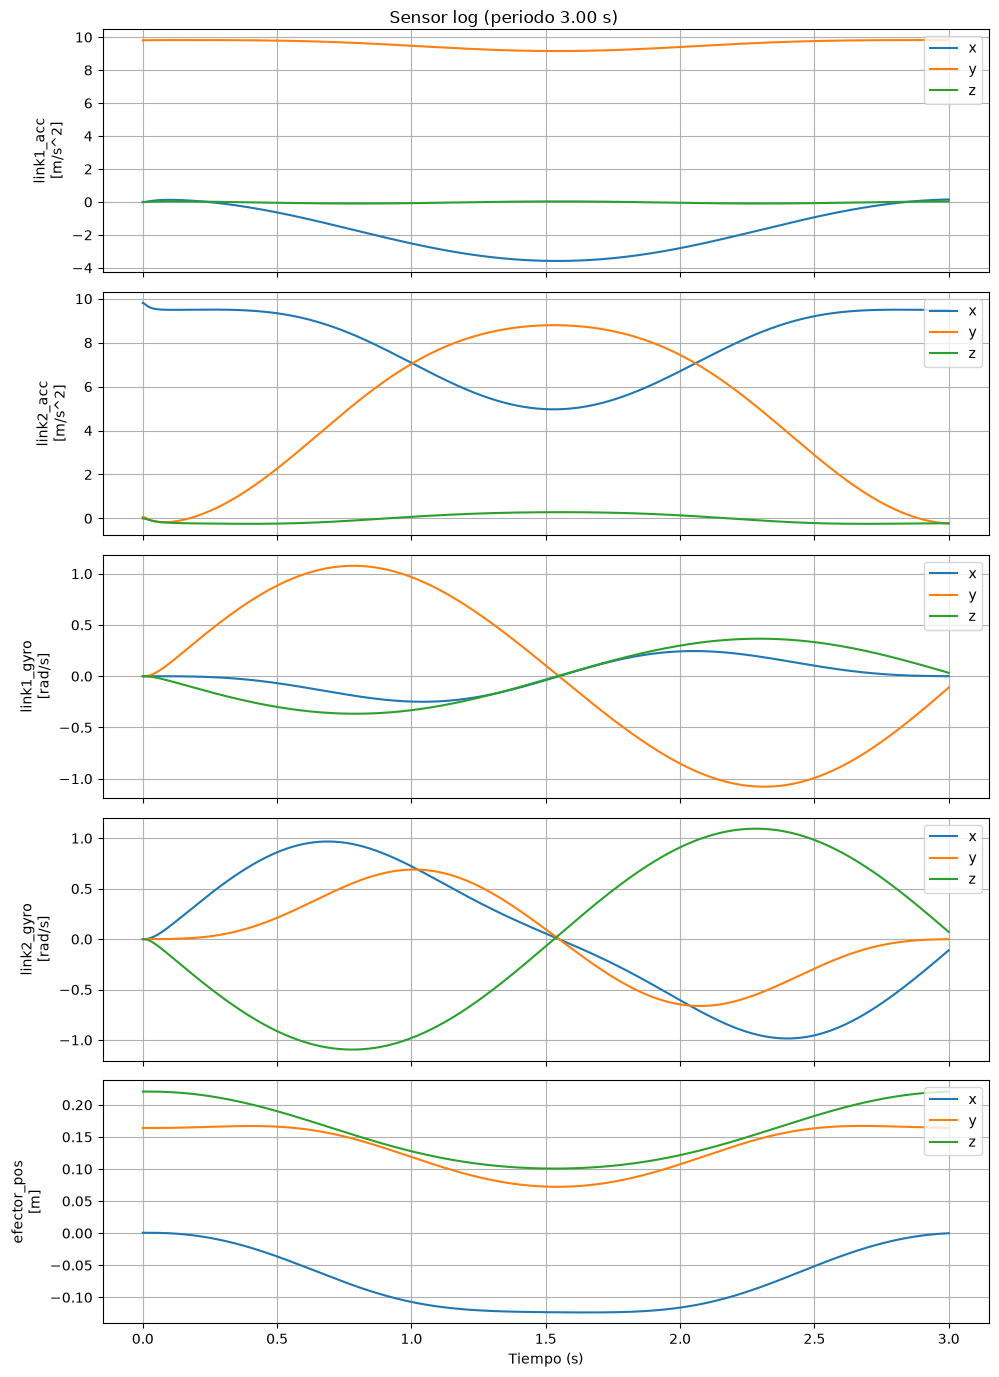

In [39]:
# --- 6. Plot Sensor Log ---
# link1_acc/link2_acc: m/s^2, sensor frame (MuJoCo accelerometer, includes gravity)
# link1_gyro/link2_gyro: rad/s, sensor frame
# efector_pos: m, world frame

fig, axes = plt.subplots(5, 1, figsize=(10, 14), sharex=True)

axes[0].plot(t, link1_acc_history)
axes[0].set_ylabel("link1_acc\n[m/s^2]")
axes[0].legend(["x", "y", "z"], loc="upper right")

axes[1].plot(t, link2_acc_history)
axes[1].set_ylabel("link2_acc\n[m/s^2]")
axes[1].legend(["x", "y", "z"], loc="upper right")

axes[2].plot(t, link1_gyro_history)
axes[2].set_ylabel("link1_gyro\n[rad/s]")
axes[2].legend(["x", "y", "z"], loc="upper right")

axes[3].plot(t, link2_gyro_history)
axes[3].set_ylabel("link2_gyro\n[rad/s]")
axes[3].legend(["x", "y", "z"], loc="upper right")

axes[4].plot(t, efector_pos_history)
axes[4].set_ylabel("efector_pos\n[m]")
axes[4].set_xlabel("Tiempo (s)")
axes[4].legend(["x", "y", "z"], loc="upper right")

for ax in axes:
    ax.grid(True)

fig.suptitle(f"Sensor log (periodo {PERIODO_S:.2f} s)")
fig.tight_layout()
plt.show()

### Brazo fisico: planificada vs. robot real vs. MuJoCo

Manda la MISMA trayectoria de arriba al brazo real y compara las tres series.

**La cuarta junta no es la misma en los dos lados.** En el XML `act` es el
paralelogramo pasivo (sin actuador, lo mueve la igualdad de tendon
`mantener_vertical`); en el brazo real ese paralelogramo es mecanico y J4 es el
giro del efector. Asi que `data.qpos[3]` no se manda nunca, `get_angles()[3]`
no tiene con que compararse, y **solo 3 de las 4 juntas son comparables**.

Los ceros del modelo y del robot ya estan verificados fisicamente, asi que el
mapeo modelo -> API es identidad en grados.

Nada de esto abre un puerto serie: el default es `DryRunArm`, y la celda que
manda al robot esta detras de `SEND_TO_ROBOT = False`.

In [40]:
# ===========================================================================
# Mapeo de juntas, limites y guarda de rango.
# ===========================================================================
#
#   API J1 <-> XML `rot`     base, yaw
#   API J2 <-> XML `link1`   hombro
#   API J3 <-> XML `link2`   codo
#   API J4 <-> NADA          ver la celda de arriba: la cuarta junta del XML es
#                            `act`, el paralelogramo pasivo, no J4.
#
# POR QUE HAY UNA GUARDA PROPIA Y NO ALCANZA LA DE pymycobot. La libreria NO
# valida los angulos en esta clase: `send_angles` pasa `angles=...` y
# `send_angle` pasa `angle=...`, pero `MyPalletizer260.calibration_parameters`
# solo mira los kwargs `degrees` y `degree`. Los chequeos nunca se disparan --
# solo `id` y `speed` se validan de verdad, y la cota de la clase es +-170 deg,
# mucho mas ancha que los limites reales de cada junta. Un valor fuera de rango
# llega al firmware sin que nadie lo mire.
#
# SIGNS/OFFSETS quedan explicitos aunque hoy sean identidad: si alguna vez se
# invierte una junta se cambia aca, y la guarda lo atrapa antes de mover nada
# (una J2 invertida barre 0 -> -20 deg, fuera del piso de -2 deg de J2).

from collections import deque

API_LIMITS_DEG = {1: (-162.0, 162.0),   # rot   / base
                  2: (  -2.0,  90.0),   # link1 / hombro
                  3: ( -92.0,  60.0),   # link2 / codo
                  4: (-180.0, 180.0)}   # efector, sin modelar

JOINT_NAMES = ["rot", "link1", "link2"]
API_IDS     = [1, 2, 3]
SIGNS       = np.array([1.0, 1.0, 1.0])   # ceros verificados fisicamente
OFFSETS_DEG = np.array([0.0, 0.0, 0.0])
J4_HOLD_DEG = 0.0                          # J4 se mantiene fijo, no se barre
VMAX_DEG_S  = 120.0                        # spec del brazo, igual que viewer.ipynb


def model_to_api_deg(q_rad):
    """(N,3) rad del modelo (rot, link1, link2) -> (N,4) grados de la API.

    La cuarta columna es J4 constante en `J4_HOLD_DEG`: la API pide 4 valores
    y el modelo solo tiene 3 juntas actuadas.
    """
    q = np.atleast_2d(np.asarray(q_rad, dtype=float))
    deg = np.rad2deg(q) * SIGNS + OFFSETS_DEG
    return np.column_stack([deg, np.full(len(deg), J4_HOLD_DEG)])


def api_deg_to_model(deg):
    """(N,4) grados de la API -> (N,3) rad del modelo. Descarta J4."""
    d = np.atleast_2d(np.asarray(deg, dtype=float))[:, :3]
    return np.deg2rad((d - OFFSETS_DEG) / SIGNS)


def check_trajectory(q_rad, model, t=None, vmax_deg_s=VMAX_DEG_S, verbose=True):
    """Valida posiciones contra XML+API y, si le pasas `t`, tambien velocidad.

    q_rad: (N,3) en rad, en coordenadas del MODELO.
    t:     (N,) en s. Sin `t` no se puede chequear velocidad y se avisa.

    Levanta ValueError antes de que nada llegue al puerto serie. Los rangos del
    XML se leen del modelo cargado, no se copian, asi que la tabla sigue siendo
    cierta si cambian los `range` del XML.

    EL CHEQUEO DE VELOCIDAD IMPORTA AL ACELERAR. Acortar el periodo no cambia
    ni una posicion -- la amplitud es la misma -- asi que la tabla de posicion
    sigue dando OK mientras el pico de velocidad crece como 1/periodo. Sin este
    chequeo, la unica guarda que hay es ciega justo al parametro que se toca.
    """
    q = np.atleast_2d(np.asarray(q_rad, dtype=float))
    if q.shape[1] != 3:
        raise ValueError(f"La trayectoria tiene {q.shape[1]} columnas; se esperan 3 "
                         "(rot, link1, link2). qpos[3] es `act` y no se manda.")
    api = model_to_api_deg(q)

    rows, bad = [], []
    for k, name in enumerate(JOINT_NAMES):
        jid = API_IDS[k]
        lo_xml, hi_xml = np.rad2deg(model.jnt_range[k])
        lo_api, hi_api = API_LIMITS_DEG[jid]
        lo, hi = api[:, k].min(), api[:, k].max()
        ok_xml = (not model.jnt_limited[k]) or (lo >= lo_xml - 1e-9 and hi <= hi_xml + 1e-9)
        ok_api = lo >= lo_api and hi <= hi_api
        rows.append((jid, name, lo, hi, lo_xml, hi_xml, lo_api, hi_api, ok_xml, ok_api))
        if not ok_xml:
            bad.append(f"J{jid}/{name}: recorrido [{lo:.1f},{hi:.1f}] deg fuera del "
                       f"rango del XML [{lo_xml:.1f},{hi_xml:.1f}]")
        if not ok_api:
            bad.append(f"J{jid}/{name}: recorrido [{lo:.1f},{hi:.1f}] deg fuera del "
                       f"limite de la API [{lo_api:.1f},{hi_api:.1f}]")

    if t is not None:
        t = np.asarray(t, dtype=float)
        qd = np.abs(np.gradient(np.rad2deg(q), t, axis=0)).max(axis=0)
        for k, name in enumerate(JOINT_NAMES):
            if qd[k] > vmax_deg_s + 1e-9:
                bad.append(f"J{API_IDS[k]}/{name}: pico de velocidad "
                           f"{qd[k]:.1f} deg/s sobre la spec del brazo "
                           f"({vmax_deg_s:.0f} deg/s) -- alarga PERIODO_S")
    else:
        qd = None

    if verbose:
        print(f"{'API':>4} {'XML':<7}{'recorrido (deg)':>18}{'rango XML':>18}"
              f"{'limite API':>18}{'pico deg/s':>12}   veredicto")
        for jid, name, lo, hi, lx, hx, la, ha, oxml, oapi in rows:
            k = API_IDS.index(jid)
            ok_v = qd is None or qd[k] <= vmax_deg_s + 1e-9
            v = "OK" if (oxml and oapi and ok_v) else "FUERA DE RANGO"
            vel = f"{qd[k]:11.1f}" if qd is not None else f"{'(sin t)':>11}"
            print(f"J{jid:<3} {name:<7}[{lo:7.1f},{hi:7.1f}]  [{lx:7.1f},{hx:7.1f}]  "
                  f"[{la:7.1f},{ha:7.1f}]{vel}   {v}")
        print(f"J4   {'-':<7}{'(sin modelar)':>18}{'-':>18}{'[ -180.0, 180.0]':>18}"
              f"{'-':>12}   se mantiene en {J4_HOLD_DEG:.1f} deg")
        if qd is None:
            print("  OJO: sin `t` no se chequeo la velocidad. Pasale el eje de "
                  "tiempo: check_trajectory(q, model, t).")
        else:
            print(f"  spec de velocidad del brazo: {vmax_deg_s:.0f} deg/s")

    if bad:
        raise ValueError("Trayectoria fuera de rango, no se manda nada:\n  - "
                         + "\n  - ".join(bad))
    return api


def resample(t, q, rate_hz):
    """Baja la trayectoria de 500 Hz a algo que entre por el puerto serie.

    Los 3141 puntos a dt=2 ms no son transmisibles: a 115200 baud y con un
    protocolo de pedido/respuesta no hay forma. ~25 Hz deja ~157 setpoints.
    """
    q = np.asarray(q, dtype=float)   # la celda 3 deja q_target como lista
    n = max(2, int(round((t[-1] - t[0]) * rate_hz)) + 1)
    t_r = np.linspace(t[0], t[-1], n)
    q_r = np.column_stack([np.interp(t_r, t, q[:, k]) for k in range(q.shape[1])])
    return t_r, q_r

In [41]:
# ===========================================================================
# Los dos brazos. Misma interfaz: send(q_rad) / read() -> (4,) grados / close().
# Mismo reparto que ReplaySensor vs DummySensor en `erp`: el codigo de arriba no
# sabe cual de los dos tiene enchufado.
# ===========================================================================

class DryRunArm:
    """Brazo simulado. NO abre ningun puerto serie.

    Modela el firmware como un lag de primer orden hacia la consigna
    RETARDADA, con tope de velocidad. No pretende ser el robot: existe para que
    todo lo demas -- el bucle de streaming, el registro, los graficos, el
    estimador de retardo -- se pueda correr y falsificar con el brazo
    desenchufado.

    latency_s:      retardo de transporte, s (consigna -> se empieza a mover)
    tau_s:          constante del lag de primer orden, s
    rate_limit_dps: tope de velocidad, deg/s
    resolution_deg: cuantizacion de la lectura. 0.01 deg es la de verdad: la
                    API transmite `int(grados * 100)` (`_angle2int`).

    El lag de primer orden no es cosmetico. Con un ZOH puro contra la consigna
    retardada, el retardo (80 ms) late contra el periodo de envio (40 ms) y la
    lectura alterna entre dos setpoints: en el grafico salen DOS bandas
    paralelas que parecen un bug del registro y no lo son. Un servo con
    realimentacion de posicion no hace eso.
    """

    def __init__(self, latency_s=0.08, tau_s=0.06, rate_limit_dps=120.0,
                 resolution_deg=0.01):
        self.latency_s = float(latency_s)
        self.tau_s = float(tau_s)
        self.rate_limit_dps = float(rate_limit_dps)
        self.resolution_deg = float(resolution_deg)
        self._queue = deque()
        self._setpoint = np.zeros(4)
        self._state = np.zeros(4)      # arranca en `home` = [0,0,0] deg
        self._t_prev = time.perf_counter()
        self.name = (f"DryRunArm(latencia={latency_s * 1e3:.0f} ms, "
                     f"tau={tau_s * 1e3:.0f} ms, vmax={rate_limit_dps:.0f} deg/s)")

    def _advance(self, now):
        while self._queue and self._queue[0][0] <= now:
            self._setpoint = self._queue.popleft()[1]
        dt = max(0.0, now - self._t_prev)
        self._t_prev = now
        move = (self._setpoint - self._state) * (1.0 - np.exp(-dt / self.tau_s))
        cap = self.rate_limit_dps * dt
        self._state = self._state + np.clip(move, -cap, cap)

    def send(self, q_rad, speed=100):
        now = time.perf_counter()
        self._advance(now)
        self._queue.append((now + self.latency_s, model_to_api_deg(q_rad)[0]))

    def read(self):
        self._advance(time.perf_counter())
        return np.round(self._state / self.resolution_deg) * self.resolution_deg

    def close(self):
        pass


class SerialArm:
    """Brazo real via pymycobot. Solo se instancia si vos lo pedis.

    ESCRITURA. Por defecto `send_radians`, que escribe y vuelve. `send_angles`
    usa `has_reply=True`: BLOQUEA esperando la respuesta del firmware en cada
    setpoint, y eso a 25 Hz no entra. El precio de `send_radians` es que no
    consume esa respuesta, asi que si el firmware contesta igual, los bytes
    quedan en el buffer de entrada y el `get_angles()` siguiente puede leer
    basura. Si la lectura vuelve rara, poner `blocking_send=True` y bajar
    `rate_hz` -- se pierde tasa pero el protocolo queda sincronizado.

    `MyPalletizer260` NO tiene `set_fresh_mode` (si lo tiene MyCobot280), asi
    que los setpoints pueden ENCOLARSE en el firmware en vez de reemplazarse, y
    el atraso se acumula. No hay forma de arreglarlo desde el host: por eso
    `plot_three_way` MIDE el retardo en vez de suponer que no existe.
    """

    def __init__(self, port, speed=100, baudrate="115200", blocking_send=False):
        from pymycobot import MyPalletizer260
        self.mc = MyPalletizer260(port, baudrate=baudrate)
        self.speed = int(speed)
        self.blocking_send = bool(blocking_send)
        self.name = f"SerialArm({port}, speed={speed}, blocking_send={blocking_send})"

    def send(self, q_rad, speed=None):
        deg = model_to_api_deg(q_rad)[0]
        sp = self.speed if speed is None else int(speed)
        if self.blocking_send:
            self.mc.send_angles([float(d) for d in deg], sp)
        else:
            # send_radians convierte a grados adentro; le pasamos los grados de
            # la API en radianes para que la conversion de vuelta sea exacta.
            self.mc.send_radians([float(r) for r in np.deg2rad(deg)], sp)

    def read(self):
        """(4,) grados de la API, o None si la respuesta no vino / vino corta."""
        a = self.mc.get_angles()
        if not isinstance(a, (list, tuple)) or len(a) < 3:
            return None                     # get_angles devuelve -1 en error
        out = np.zeros(4)
        out[:min(4, len(a))] = a[:4]
        return out

    def close(self):
        try:
            self.mc._serial_port.close()
        except Exception:
            pass

In [42]:
# ===========================================================================
# Sensores: las dos IMUs del Teensy 3.6, en el layout de sensordata de MuJoCo.
# ===========================================================================
#
# Las clases viven en `erp.sensors` (y el log en `erp.io`); aca queda solo la
# CONFIGURACION de este brazo. Espejo de `sensors.palletizer_imu` en
# config/estimation.yaml -- si cambias algo aca, cambialo alla.
#
# Por que el layout y no las columnas crudas: cada muestra sale como un
# `Measurement` con `z` ya ordenado como `sensordata[rows]`, con `rows` y `R`
# pegados. El EKF, cuando se enchufe, hace `y = m.z - h(x)[m.rows]` sin saber
# de que puerto vino. Y las 12 columnas van JUNTAS en una sola medicion: un
# update de 12 canales cuesta ~360 us, cuatro updates de 3 canales ~1.4 ms.
#
# El Teensy ignora el baudrate (USB nativo), asi que el largo de la linea no
# limita la tasa: la pone el loop del firmware (hoy ~20 Hz, 50 ms).
#
# TIEMPO. Todo sale en `time.perf_counter()` ABSOLUTO, sin restar t0 adentro de
# los sensores. Hoy el firmware no manda sello propio, asi que se sella al
# llegar (`ArrivalClock`): se come la latencia USB como sesgo + jitter. Cuando
# las lineas traigan `micros:<n>`, pasar `clock=ClockSync(1e-6)` y listo.

from erp.io import MeasurementLog
from erp.sensors import ArrivalClock, ClockSync, IMUDecoder, ReplaySensor, SerialIMUSensor, SimSensor
from erp.sensors.mujoco import make_R, rows_of

# Orden en que el Teensy manda los canales (= columnas del CSV crudo viejo).
IMU_KEYS = [
    "IMU_0.ax", "IMU_0.ay", "IMU_0.az",
    "IMU_1.ax", "IMU_1.ay", "IMU_1.az",
    "IMU_0.wx", "IMU_0.wy", "IMU_0.wz",
    "IMU_1.wx", "IMU_1.wy", "IMU_1.wz",
]

# Sensor de MuJoCo -> canales del Teensy. ACA vive el cableado fisico:
# IMU_0 esta en link1 e IMU_1 en link2. El orden de las claves es el del bloque
# <sensor> del XML, asi `rows_of` devuelve filas contiguas.
#
# Ejes del chip -> ejes del site de MuJoCo (z_site = M @ z_chip), por bloque.
# Acc y gyro del mismo chip llevan la MISMA matriz: son los mismos ejes fisicos.
# Las dos son giros de 90 deg alrededor de z (el eje de las juntas link1/link2),
# en sentidos opuestos, y ambas con det +1 (rotaciones propias, no espejos).
#
# COMO SE SACARON (2026-09-16), no a ojo: se simulo la misma trayectoria en
# MuJoCo y, para cada asignacion chip->link, se barrio el retardo y las 48
# permutaciones con signo, minimizando el error de gyro + acc. Dos corridas
# reales INDEPENDIENTES dan el mismo resultado:
#
#                                       gyro rms [rad/s]   acc rms [m/s^2]
#   IMU_1->link1, IMU_0->link2 (antes)     0.34 / 0.35        2.5 / 2.7
#   IMU_0->link1, IMU_1->link2 (ahora)     0.10 / 0.07        0.38 / 0.27   (14:02)
#                                          0.06 / 0.08        0.38 / 0.37   (9 sep, CSV crudo)
#
# Con la asignacion de antes ninguna permutacion cerraba: la mejor dejaba la
# desviacion de un eje del gyro 3x distinta de la simulada. La de ahora iguala
# todas las desviaciones (gyro y acc) dentro de ~10%. En reposo, gravedad
# mapeada: link1 [-0.04, 9.77, -0.51] vs sim [-0.02, 9.81, 0]; link2 [9.63, 0.33,
# 0.08] vs sim [9.81, 0.06, 0]. Lo que sobra (p. ej. -0.5 m/s^2 en z de IMU_0) es
# bias/inclinacion de montaje: le toca a la calibracion, no al mapeo de ejes.
IMU_LAYOUT = {
    "link1_acc":  ("IMU_0.ax", "IMU_0.ay", "IMU_0.az"),
    "link2_acc":  ("IMU_1.ax", "IMU_1.ay", "IMU_1.az"),
    "link1_gyro": ("IMU_0.wx", "IMU_0.wy", "IMU_0.wz"),
    "link2_gyro": ("IMU_1.wx", "IMU_1.wy", "IMU_1.wz"),
}
M_IMU0_LINK1 = [[0, 1, 0], [-1, 0, 0], [0, 0, 1]]   # Rz(-90): x_site = y_chip, y_site = -x_chip
M_IMU1_LINK2 = [[0, -1, 0], [1, 0, 0], [0, 0, 1]]   # Rz(+90): x_site = -y_chip, y_site = x_chip
IMU_AXIS_MAPS = {
    "link1_acc": M_IMU0_LINK1, "link1_gyro": M_IMU0_LINK1,
    "link2_acc": M_IMU1_LINK2, "link2_gyro": M_IMU1_LINK2,
}

SIG_ACC = 0.05       # m/s^2 por canal -- placeholder hasta calibrar R
SIG_GYRO = 0.005     # rad/s por canal -- placeholder hasta calibrar R
IMU_RATE_HZ = 20     # medido en el log: 50 +- 1 ms entre lineas

# El log se guarda CRUDO (columnas IMU_0.ax, ...; mismo formato que el viejo
# `imu_trajectory_log.csv`) y se decodifica al leerlo con la configuracion
# ACTUAL. Asi, corregir el cableado, los ejes o el bias arregla tambien los logs
# viejos. Guardar `z` ya decodificado congelaba la configuracion del dia: el
# `imu_trajectory_layout.csv` de la primera corrida quedo con el cableado al
# reves en los nombres de columna.
IMU_CSV_PATH = repo_root / "data" / "raw" / "imu_trajectory_raw.csv"

imu_decoder = IMUDecoder(IMU_KEYS, IMU_LAYOUT, IMU_AXIS_MAPS)
IMU_ROWS = rows_of(model, *IMU_LAYOUT)
IMU_R = make_R(model, SIG_ACC, SIG_GYRO)[np.ix_(IMU_ROWS, IMU_ROWS)]


def make_imu_sensor(port, clock=None):
    """SerialIMUSensor del Teensy con la configuracion de esta celda.

    No abre el puerto: eso pasa en `start()` / al entrar al `with`. Las lineas
    que no son datos (banner de arranque, prints de debug) se imprimen con el
    prefijo [IMU] en vez de descartarse en silencio.
    """
    return SerialIMUSensor(port, imu_decoder, IMU_ROWS, IMU_R, name="imu",
                           clock=clock if clock is not None else ArrivalClock(0.0),
                           on_text=lambda s: print(f"[IMU] {s}"))


def sensor_report(sensors, mlog):
    """Una linea por sensor: cuanto llego, cuanto se logueo, cuanto se perdio."""
    for s in sensors:
        counters = ", ".join(f"{k} {getattr(s, k)}" for k in ("received", "rejected", "overruns")
                             if hasattr(s, k))
        print(f"  {s.name:6s}: logueadas {mlog.count(s.name)}" + (f" ({counters})" if counters else ""))


print("filas de sensordata de las IMUs:", IMU_ROWS)
print("columnas:", imu_decoder.column_names())

filas de sensordata de las IMUs: [ 0  1  2  3  4  5  6  7  8  9 10 11]
columnas: ['link1_acc_x', 'link1_acc_y', 'link1_acc_z', 'link2_acc_x', 'link2_acc_y', 'link2_acc_z', 'link1_gyro_x', 'link1_gyro_y', 'link1_gyro_z', 'link2_gyro_x', 'link2_gyro_y', 'link2_gyro_z']


In [43]:
# ===========================================================================
# Bucle de streaming, replay en MuJoCo, y estimador de retardo.
# ===========================================================================

def run_trajectory(arm, t, q_rad, rate_hz=25.0, speed=100, read=True, read_every=10,
                   verbose=True, sensors=(), mlog=None, t0=None):
    """Manda la trayectoria al brazo y registra consigna y medida POR SEPARADO.

    Devuelve un dict con `t_cmd`/`q_cmd_deg` (lo que se mando, sellado justo
    ANTES de escribir) y `t_meas`/`q_meas_deg` (lo que devolvio la lectura,
    sellado justo DESPUES de leer). Los tiempos son segundos desde `t0`; los
    angulos, grados de la API. `t0` (absoluto, `perf_counter`) tambien vuelve
    en el dict: es lo que pone a los sensores en el mismo eje que `t_cmd`.

    sensors: objetos `erp.sensors.Sensor`. En CADA tick, despues del `send`, se
             les hace `drain()` (no bloquea) y todo va a `mlog`
             (`erp.io.MeasurementLog`). Al final se vacian una vez mas.
    t0:      si ya lo tomaste afuera (p. ej. para alinear un `SimSensor`),
             pasalo; si no, se toma al arrancar.

    ESTE `drain` ES EL PUNTO DE ENGANCHE DEL EKF. Cuando exista el paso de
    fusion, se llama aca mismo con lo drenado, sin reestructurar el bucle. Por
    eso los sensores leen en su propio thread y este bucle nunca espera un
    puerto: el ritmo de consignas no depende de la tasa de las IMUs.

    Dos reglas, las mismas que documenta `SimLog` en viewer.ipynb:

    1. Cada muestra se sella con `time.perf_counter()` en el momento de la
       llamada. NUNCA se asume que la tasa nominal se cumplio: `time.sleep` en
       Windows tiene granularidad de milisegundos y el puerto serie agrega lo
       suyo. La tasa lograda y el jitter se miden y se informan.
    2. Consigna y medida quedan como series distintas, con ejes de tiempo
       distintos. Estan separadas por un viaje de ida y vuelta del puerto:
       meterlas en la misma fila como si fueran del mismo instante es
       exactamente el sesgo de un paso contra el que avisa `SimLog`, y no se ve
       en el grafico -- aparece despues como sesgo del filtro.
    """
    if sensors and mlog is None:
        raise ValueError("con `sensors` hace falta un `mlog` donde guardar lo drenado")
    t_r, q_r = resample(t, q_rad, rate_hz)
    t_cmd = np.empty(len(t_r))
    q_cmd = np.empty((len(t_r), 4))
    t_meas, q_meas = [], []

    if t0 is None:
        t0 = time.perf_counter()
    for i in range(len(t_r)):
        deadline = t0 + t_r[i]
        now = time.perf_counter()
        if now < deadline:
            time.sleep(deadline - now)
        t_cmd[i] = time.perf_counter() - t0
        q_cmd[i] = model_to_api_deg(q_r[i])[0]
        arm.send(q_r[i], speed=speed)
        for s in sensors:                  # <-- enganche del EKF, a futuro
            mlog.extend(s.drain())
        if read:
            if i % read_every == 0:
                m = arm.read()
                if m is not None:
                    t_meas.append(time.perf_counter() - t0)
                    q_meas.append(m)
    for s in sensors:
        mlog.extend(s.drain())

    gaps = np.diff(t_cmd)
    log = dict(t_cmd=t_cmd, q_cmd_deg=q_cmd,
               t_meas=np.asarray(t_meas),
               q_meas_deg=np.asarray(q_meas) if q_meas else np.empty((0, 4)),
               rate_nominal=rate_hz,
               rate_achieved=(len(t_cmd) - 1) / (t_cmd[-1] - t_cmd[0]),
               jitter_ms=float(np.std(gaps) * 1e3),
               arm=getattr(arm, "name", str(arm)),
               t0=t0)
    if verbose:
        print(log["arm"])
        print(f"  setpoints enviados : {len(t_cmd)} en {t_cmd[-1]:.3f} s")
        print(f"  tasa nominal       : {rate_hz:.1f} Hz")
        print(f"  tasa lograda       : {log['rate_achieved']:.2f} Hz "
              f"(jitter {log['jitter_ms']:.2f} ms, peor hueco {gaps.max() * 1e3:.1f} ms)")
        print(f"  lecturas recibidas : {len(t_meas)}")
        if read and len(t_meas) < len(t_cmd) // 2:
            print("  OJO: se perdieron mas de la mitad de las lecturas. Con "
                  "SerialArm suele ser el buffer desincronizado -> probar "
                  "blocking_send=True y menos rate_hz.")
        if sensors:
            print("  sensores:")
            sensor_report(sensors, mlog)
    return log


def simulate(model, data, t, q_rad, warmup_steps=100):
    """Repite los MISMOS setpoints en MuJoCo, a paso de fisica.

    Devuelve (t_sim, q_sim): tiempo de simulacion y qpos[:3] en rad, ambos
    POSTERIORES al paso. Se devuelve `data.time` en vez de reusar `t` porque
    qpos ya es de t+dt cuando `mj_step` vuelve; con el eje propio las dos
    mitades quedan etiquetadas con el instante que de verdad les corresponde.
    """
    q_rad = np.asarray(q_rad, dtype=float)   # idem: puede venir como lista
    mj.mj_resetDataKeyframe(model, data, model.key("home").id)
    # Mismo calentamiento que la celda de simulacion: 0.2 s en el primer punto
    # para que la carga de gravedad no entre como transitorio, y reloj a 0.
    data.ctrl[:3] = q_rad[0]
    for _ in range(warmup_steps):
        mj.mj_step(model, data)
    data.time = 0.0
    t_sim = np.empty(len(t))
    q_sim = np.empty((len(t), 3))
    for i in range(len(t)):
        data.ctrl[:3] = q_rad[i]
        mj.mj_step(model, data)
        t_sim[i] = data.time
        q_sim[i] = data.qpos[:3]
    return t_sim, q_sim


def estimate_lag(t_ref, q_ref_deg, t_meas, q_meas_deg, max_lag_s=0.6, n=241):
    """Retardo, en s, que mejor alinea la medida con la consigna (RMS minimo).

    Positivo = la medida va ATRASADA respecto de la consigna. Se barre el
    retardo y se interpola la consigna corrida sobre los sellos de tiempo
    REALES de la medida, no sobre los nominales. Solo se usan las muestras que
    caen dentro de la ventana valida, para que el arranque no invente
    correlacion donde no la hay.
    """
    if len(t_meas) < 4:
        return float("nan")
    inside = (t_meas >= t_ref[0] + max_lag_s) & (t_meas <= t_ref[-1])
    if inside.sum() < 4:
        return float("nan")
    tm, qm = t_meas[inside], q_meas_deg[inside]
    best, best_lag = np.inf, float("nan")
    for lag in np.linspace(0.0, max_lag_s, n):
        ref = np.column_stack([np.interp(tm - lag, t_ref, q_ref_deg[:, k])
                               for k in range(q_ref_deg.shape[1])])
        rms = float(np.sqrt(np.mean((qm - ref) ** 2)))
        if rms < best:
            best, best_lag = rms, lag
    return best_lag

In [44]:
import pandas as pd
df = pd.read_csv("../data/raw/imu_trajectory_log.csv")


In [45]:
# ===========================================================================
# Grafico de las tres series.
# ===========================================================================
#
# El color identifica la FUENTE (planificada / MuJoCo / robot), no la junta:
# cada panel es una junta, y adentro de cada panel se comparan las tres
# fuentes. El color se acompana de trazo o marcador distinto, asi que la
# identidad nunca depende solo del color.
#
# El robot se dibuja con MARCADORES a su tasa nativa (~25 Hz), sin interpolar
# hasta los 500 Hz de los otros dos: que sea ralo es informacion, no un defecto
# del grafico. Interpolarlo lo haria parecer tan denso como la simulacion.

C_TARGET, C_SIM, C_REAL = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK2, MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, AXIS, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"


def _style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(AXIS)
        ax.spines[side].set_linewidth(1.0)
    ax.tick_params(colors=MUTED, labelsize=9, length=0)
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(INK2)


def _header(fig, axes, title, ncols):
    """Titulo y leyenda en coordenadas de figura, arriba de los ejes.

    A mano y no con constrained_layout: la leyenda adentro de los ejes tapa la
    curva de J1 -- justo la que mas se despega de la consigna -- y si se deja
    que `suptitle` y una leyenda `outside` negocien el mismo renglon, se pisan.
    """
    fig.subplots_adjust(left=0.105, right=0.985, top=0.882, bottom=0.075, hspace=0.13)
    fig.text(0.010, 0.975, title, color=INK, fontsize=13, ha="left", va="top")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="upper left",
               bbox_to_anchor=(0.008, 0.942), frameon=False, fontsize=9.5,
               labelcolor=INK2, ncols=ncols)


def plot_three_way(t, q_target, t_sim, q_sim, log, title_suffix=""):
    """Planificada vs. MuJoCo vs. robot real, por junta, mas el error.

    t, q_target : eje y consigna a 500 Hz, rad (coordenadas del modelo)
    t_sim, q_sim: salida de `simulate`, rad
    log         : salida de `run_trajectory`, grados de la API
    """
    q_target = np.asarray(q_target, dtype=float)
    tgt = np.rad2deg(q_target)
    sim = np.rad2deg(q_sim)
    tm = log["t_meas"]
    real = log["q_meas_deg"][:, :3] if len(tm) else np.empty((0, 3))
    lag = estimate_lag(t, tgt, tm, real)

    fig, axes = plt.subplots(3, 1, figsize=(9.5, 8.0), sharex=True, facecolor=SURFACE)
    for k, ax in enumerate(axes):
        _style(ax)
        ax.plot(t, tgt[:, k], color=C_TARGET, lw=2.0, ls="--", zorder=3,
                label="Planificada (consigna)")
        ax.plot(t_sim, sim[:, k], color=C_SIM, lw=2.0, ls="-", zorder=2,
                label="MuJoCo (qpos)")
        if len(tm):
            ax.plot(tm, real[:, k], color=C_REAL, ls="none", marker="o", ms=4.5,
                    mew=1.2, mec=SURFACE, zorder=4, label="Robot real (get_angles)")
        ax.set_ylabel(f"J{API_IDS[k]} · {JOINT_NAMES[k]}\n[grados]",
                      color=INK2, fontsize=10)
    axes[-1].set_xlabel("Tiempo [s]", color=INK2, fontsize=10)
    _header(fig, axes, "Seguimiento por junta: planificada vs. MuJoCo vs. "
                       "robot real" + title_suffix, ncols=3)

    fig2, axes2 = plt.subplots(3, 1, figsize=(9.5, 6.5), sharex=True, facecolor=SURFACE)
    for k, ax in enumerate(axes2):
        _style(ax)
        ax.axhline(0.0, color=AXIS, lw=1.0, zorder=1)
        ax.plot(t_sim, sim[:, k] - np.interp(t_sim, t, tgt[:, k]),
                color=C_SIM, lw=2.0, zorder=2, label="MuJoCo − planificada")
        if len(tm):
            ax.plot(tm, real[:, k] - np.interp(tm, t, tgt[:, k]),
                    color=C_REAL, ls="none", marker="o", ms=4.5, mew=1.2,
                    mec=SURFACE, zorder=3, label="Robot real − planificada")
        ax.set_ylabel(f"J{API_IDS[k]} · {JOINT_NAMES[k]}\n[grados]",
                      color=INK2, fontsize=10)
    axes2[-1].set_xlabel("Tiempo [s]", color=INK2, fontsize=10)
    _header(fig2, axes2, f"Error contra la consigna  ·  retardo estimado del "
                         f"brazo {lag * 1e3:.0f} ms" + title_suffix, ncols=2)

    e_sim = sim - np.column_stack([np.interp(t_sim, t, tgt[:, k]) for k in range(3)])
    print(f"\nRMS contra la consigna [deg]   ({'  '.join(JOINT_NAMES)})")
    print("  MuJoCo    :", np.round(np.sqrt((e_sim ** 2).mean(axis=0)), 4))
    if len(tm):
        e_real = real - np.column_stack([np.interp(tm, t, tgt[:, k]) for k in range(3)])
        print("  Robot real:", np.round(np.sqrt((e_real ** 2).mean(axis=0)), 4))
        print(f"  retardo estimado del brazo: {lag * 1e3:.0f} ms")
    print("\n  El error grande de J1 en MuJoCo NO es del grafico: `rot_servo` "
          "tiene kp=1.62 y\n  forcerange +-4 N*m contra kp=63.35 de link1, asi "
          "que atrasa la consigna varios\n  grados en un seno de 60 deg. Es el "
          "modelo, y hay que mirarlo antes de culpar\n  al brazo real.")
    return fig, fig2, lag

 API XML       recorrido (deg)         rango XML        limite API  pico deg/s   veredicto
J1   rot    [    0.0,   60.0]  [ -159.9,  159.9]  [ -162.0,  162.0]       62.8   OK
J2   link1  [    0.0,   20.0]  [    0.0,   90.0]  [   -2.0,   90.0]       20.9   OK
J3   link2  [    0.0,   40.0]  [    0.0,   60.2]  [  -92.0,   60.0]       41.9   OK
J4   -           (sin modelar)                 -  [ -180.0, 180.0]           -   se mantiene en 0.0 deg
  spec de velocidad del brazo: 120 deg/s
DryRunArm(latencia=80 ms, tau=60 ms, vmax=120 deg/s)
  setpoints enviados : 76 en 3.000 s
  tasa nominal       : 25.0 Hz
  tasa lograda       : 25.01 Hz (jitter 0.34 ms, peor hueco 40.8 ms)
  lecturas recibidas : 8
  OJO: se perdieron mas de la mitad de las lecturas. Con SerialArm suele ser el buffer desincronizado -> probar blocking_send=True y menos rate_hz.
  sensores:
  imu   : logueadas 60
  IMU simulada: 60 de 61 muestras (las que caen dentro de los ultimos 5 ms de latencia no llegan a salir)

RMS con

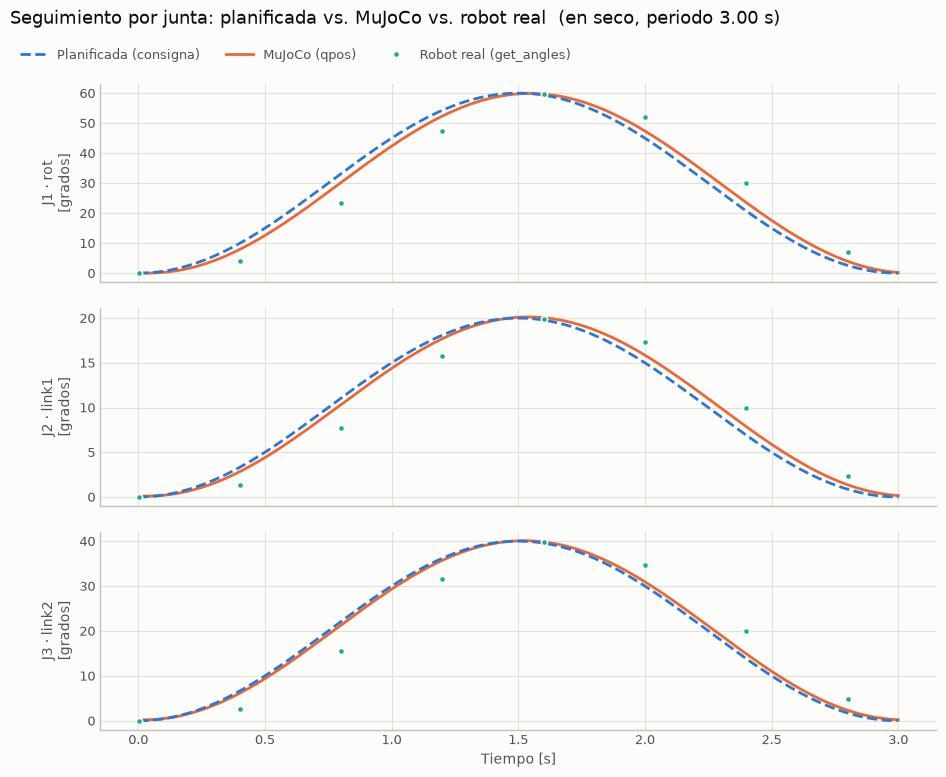

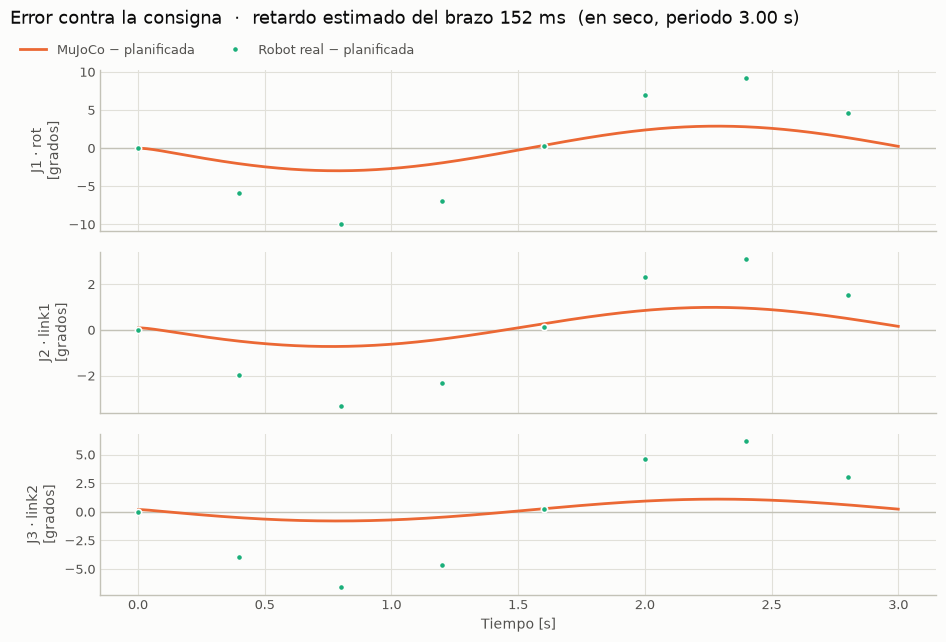

In [46]:
# ===========================================================================
# CORRIDA EN SECO. No abre ningun puerto serie: `DryRunArm` no toca hardware.
# ===========================================================================

# STREAM_RATE_HZ NO ES LA PERILLA DE VELOCIDAD. Es cada cuanto se manda un
# setpoint; subirla manda mas puntos de la MISMA trayectoria, no la acelera.
# Para que el brazo vaya mas rapido se acorta PERIODO_S en la celda de arriba.
#
# Y subirla de mas es contraproducente: a 100 Hz cada vuelta del bucle tiene un
# `send` mas un `get_angles` (que es un viaje de ida y vuelta por el serie), no
# entra en 10 ms, y el bucle se atrasa -- `run_trajectory` lo informa como
# "tasa lograda" muy por debajo de la nominal. Peor: como MyPalletizer260 no
# tiene `set_fresh_mode`, los setpoints de mas se ENCOLAN en el firmware y el
# atraso se acumula durante toda la corrida. 25 Hz sobre un ciclo de 3 s son 75
# muestras, de sobra para un seno.
STREAM_RATE_HZ = 25
STREAM_SPEED = 100        # 1..100 de la API. No es deg/s: es la escala del firmware.

# La guarda corre ANTES que cualquier otra cosa. Si la trayectoria se sale de
# rango -- de posicion O de velocidad -- levanta aca y no llega a existir un
# brazo al que mandarsela. El `t` es lo que le permite chequear la velocidad.
api_deg = check_trajectory(q_target, model, t)

# IMU simulada: el `sensor_log_sim` de la celda de simulacion, bajado a la tasa
# del Teensy, con ruido N(0, IMU_R) y 5 ms de latencia de transporte. Sale en
# el MISMO bucle y por la MISMA interfaz que el `SerialIMUSensor` real, asi que
# esto prueba la plomeria entera (drain por tick, log, ventana) sin hardware.
# `t0` se toma afuera para que los sellos de la IMU simulada y los de
# `run_trajectory` compartan origen.
arm = DryRunArm(latency_s=0.08, tau_s=0.06, rate_limit_dps=120.0)
t0_dry = time.perf_counter()
imu_sim = SimSensor(t, sensor_log_sim, rows=IMU_ROWS, R=IMU_R, name="imu",
                    rate_hz=IMU_RATE_HZ, latency_s=0.005,
                    t_shift=t0_dry, clock=time.perf_counter)
mlog_dry = MeasurementLog()
log = run_trajectory(arm, t, q_target, rate_hz=STREAM_RATE_HZ, speed=STREAM_SPEED,
                     sensors=[imu_sim], mlog=mlog_dry, t0=t0_dry)
arm.close()

esperadas = imu_sim.truth_t.size
print(f"  IMU simulada: {mlog_dry.count('imu')} de {esperadas} muestras "
      f"(las que caen dentro de los ultimos 5 ms de latencia no llegan a salir)")

t_sim, q_sim = simulate(model, data, t, q_target)
fig, fig2, lag = plot_three_way(t, q_target, t_sim, q_sim, log,
                                title_suffix=f"  (en seco, periodo {PERIODO_S:.2f} s)")
plt.show()

In [47]:
# ===========================================================================
# CHEQUEOS NEGATIVOS. Una guarda que no puede dispararse no prueba nada.
# ===========================================================================
# Las tres trayectorias de abajo TIENEN que ser rechazadas antes de mandar nada.
# La tercera es la que cubre el caso nuevo: acortar el periodo no mueve ni una
# posicion, asi que solo el chequeo de velocidad la puede atrapar.

print("chequeos negativos (la guarda tiene que disparar en los tres):\n")
_casos = [
    ("J3 llega a 80 deg", [30, 10, 20 * 2], [1.0,  1.0, 1.0], PERIODO_S),
    ("J2 invertida",      [30, 10, 20],     [1.0, -1.0, 1.0], PERIODO_S),
    ("periodo 1.0 s",     [30, 10, 20],     [1.0,  1.0, 1.0], 1.0),
]
for etiqueta, amps_deg, signos, periodo in _casos:
    _signs_backup = SIGNS.copy()
    SIGNS[:] = signos
    try:
        _w = 2 * np.pi / periodo
        _t = np.linspace(0, periodo, int(periodo / dt))
        _amps = np.deg2rad(amps_deg)
        q_malo = np.sin(_w * _t - np.pi / 2)[:, None] * _amps + _amps
        try:
            check_trajectory(q_malo, model, _t, verbose=False)
            print(f"  {etiqueta:20s} NO disparo  <-- MAL, la guarda no sirve")
        except ValueError as exc:
            print(f"  {etiqueta:20s} rechazada OK")
            for linea in str(exc).splitlines()[1:]:
                print(f"      {linea.strip()}")
    finally:
        SIGNS[:] = _signs_backup

# Y el control positivo: sin `t` la guarda NO ve la velocidad, asi que el mismo
# periodo de 1.0 s pasa. Es la razon por la que las dos llamadas de verdad le
# pasan el eje de tiempo.
_w = 2 * np.pi / 1.0
_t = np.linspace(0, 1.0, int(1.0 / dt))
_amps = np.deg2rad([30, 10, 20])
q_rapido = np.sin(_w * _t - np.pi / 2)[:, None] * _amps + _amps
try:
    check_trajectory(q_rapido, model, verbose=False)      # <-- sin t, a proposito
    print("\n  periodo 1.0 s SIN pasarle `t`: pasa la guarda, como se espera.")
    print("  Por eso las llamadas reales usan check_trajectory(q, model, t).")
except ValueError:
    print("\n  <-- inesperado: sin `t` no deberia poder ver la velocidad")

chequeos negativos (la guarda tiene que disparar en los tres):

  J3 llega a 80 deg    rechazada OK
      - J3/link2: recorrido [0.0,80.0] deg fuera del rango del XML [0.0,60.2]
      - J3/link2: recorrido [0.0,80.0] deg fuera del limite de la API [-92.0,60.0]
  J2 invertida         rechazada OK
      - J2/link1: recorrido [-20.0,0.0] deg fuera del rango del XML [0.0,90.0]
      - J2/link1: recorrido [-20.0,0.0] deg fuera del limite de la API [-2.0,90.0]
  periodo 1.0 s        rechazada OK
      - J1/rot: pico de velocidad 188.5 deg/s sobre la spec del brazo (120 deg/s) -- alarga PERIODO_S
      - J3/link2: pico de velocidad 125.7 deg/s sobre la spec del brazo (120 deg/s) -- alarga PERIODO_S

  periodo 1.0 s SIN pasarle `t`: pasa la guarda, como se espera.
  Por eso las llamadas reales usan check_trajectory(q, model, t).


 API XML       recorrido (deg)         rango XML        limite API  pico deg/s   veredicto
J1   rot    [    0.0,   60.0]  [ -159.9,  159.9]  [ -162.0,  162.0]       62.8   OK
J2   link1  [    0.0,   20.0]  [    0.0,   90.0]  [   -2.0,   90.0]       20.9   OK
J3   link2  [    0.0,   40.0]  [    0.0,   60.2]  [  -92.0,   60.0]       41.9   OK
J4   -           (sin modelar)                 -  [ -180.0, 180.0]           -   se mantiene en 0.0 deg
  spec de velocidad del brazo: 120 deg/s
angulos actuales: [ 46.14  93.77 -26.01  -5.53]
yendo al inicio [0. 0. 0. 0.] deg a speed=30 ...
angulos al inicio: [ 0.43  1.66  0.61 -0.61]
SerialArm(COM6, speed=100, blocking_send=False)
  setpoints enviados : 76 en 3.000 s
  tasa nominal       : 25.0 Hz
  tasa lograda       : 25.00 Hz (jitter 0.25 ms, peor hueco 40.6 ms)
  lecturas recibidas : 0

RMS contra la consigna [deg]   (rot  link1  link2)
  MuJoCo    : [2.0681 0.6189 0.693 ]

  El error grande de J1 en MuJoCo NO es del grafico: `rot_servo` tiene

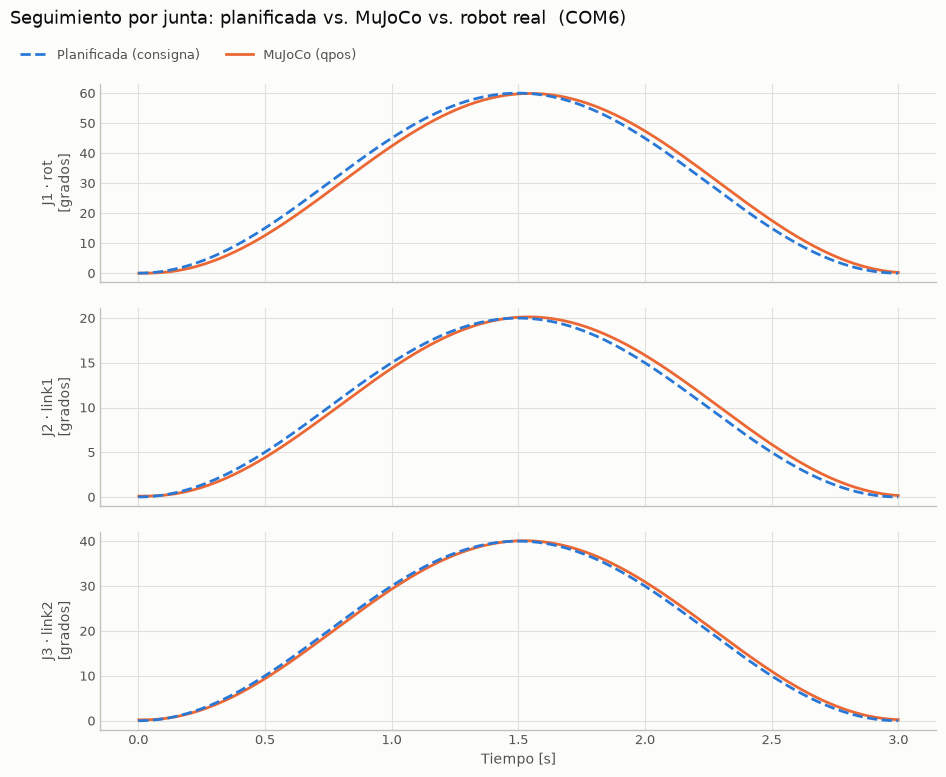

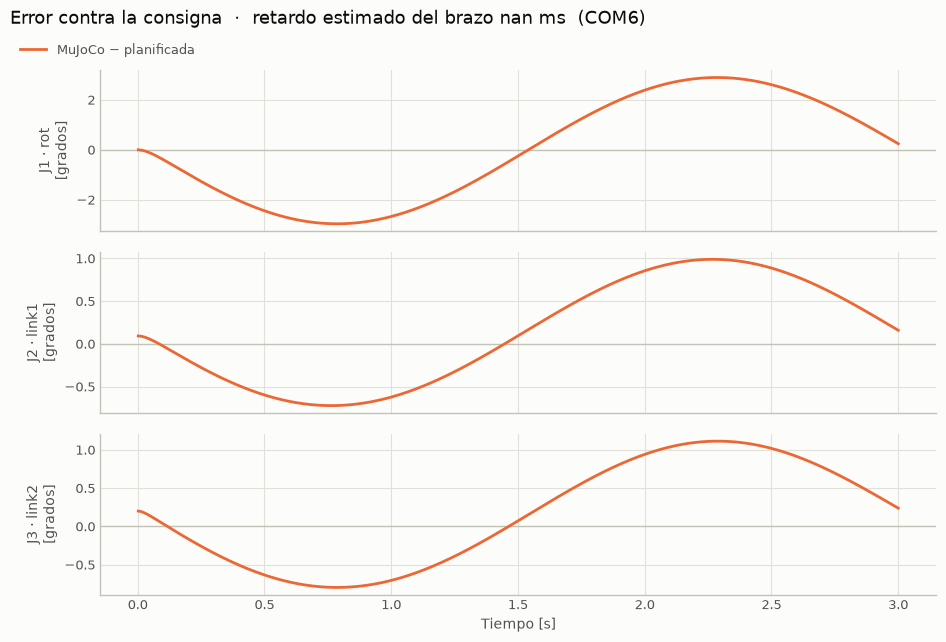

In [48]:
# ===========================================================================
# ROBOT REAL. APAGADO. Correr el notebook entero no abre ningun puerto serie.
# ===========================================================================
#
# Antes de poner SEND_TO_ROBOT = True:
#   - calibracion hecha (los ceros del robot y del modelo coinciden);
#   - espacio libre alrededor: J1 barre 60 deg desde el `home`;
#   - la celda de arriba corrio y la trayectoria dio OK en la tabla;
#   - una mano en el boton de apagado la primera vez.
#
# El brazo arranca donde este, no en `home`. El primer setpoint es [0,0,0] deg,
# asi que si esta lejos, el primer movimiento es el mas grande de todo el
# barrido y lo hace a `speed` -- por eso el `send_angles` de posicionamiento
# inicial, que es BLOQUEANTE y espera a que llegue antes de empezar a barrer.

SEND_TO_ROBOT = True        # <-- el unico interruptor
PORT = "COM6"                # el mismo de Palletizer.ipynb
HOMING_SPEED = 30            # 1..100. DESPACIO a proposito: este movimiento
                             # es el unico sin perfil -- va de donde este el
                             # brazo hasta [0,0,0] en linea recta de juntas, y
                             # puede ser mas grande que todo el barrido junto.

if SEND_TO_ROBOT:
    api_deg = check_trajectory(q_target, model, t)

    arm = SerialArm(PORT, speed=STREAM_SPEED, blocking_send=False)
    try:
        print("angulos actuales:", arm.read())
        print(f"yendo al inicio {api_deg[0]} deg a speed={HOMING_SPEED} ...")
        arm.mc.sync_send_angles([float(d) for d in api_deg[0]], HOMING_SPEED)
        time.sleep(0.5)
        print("angulos al inicio:", arm.read())

        log_real = run_trajectory(arm, t, q_target, rate_hz=STREAM_RATE_HZ, read=False,
                                  speed=STREAM_SPEED)
    finally:
        arm.close()                                  # el puerto se cierra igual

    t_sim, q_sim = simulate(model, data, t, q_target)
    fig, fig2, lag = plot_three_way(t, q_target, t_sim, q_sim, log_real,
                                    title_suffix=f"  ({PORT})")
    plt.show()

    np.savez_compressed(repo_root / "data" / "raw" / "palletizer_traj.npz",
                        t=t, q_target=q_target, t_sim=t_sim, q_sim=q_sim,
                        t_cmd=log_real["t_cmd"], q_cmd_deg=log_real["q_cmd_deg"],
                        t_meas=log_real["t_meas"], q_meas_deg=log_real["q_meas_deg"])
else:
    print("SEND_TO_ROBOT = False -> no se abrio ningun puerto serie.")

In [49]:
# ===========================================================================
# ROBOT REAL + LOG DE IMUs, log acotado a la ventana de la trayectoria.
# ===========================================================================
#
# Antes esta celda tenia su propio lector serie en el thread principal, el
# brazo en un thread aparte y tres `threading.Event` para abrir y cerrar la
# ventana de log. Ahora:
#
# - `SerialIMUSensor` lee el Teensy en SU thread y encola `Measurement`s.
# - El brazo corre en el thread principal, en `run_trajectory`, que en cada
#   tick hace `imu.drain()` hacia `mlog_real`. Ese drain es donde va a ir el EKF.
# - La ventana se corta por SELLO DE TIEMPO (`mlog.window(t0, t_fin)`), no con
#   eventos: lo que llego durante el homing se descarta con un drain justo
#   antes de `t0`.
#
# Arreglos de paso respecto de la version con eventos:
# - el sello ya no cambia de base en silencio: antes, si la linea traia `t` o
#   `millis`, la columna pasaba de segundos de host a unidades del Teensy;
# - las lineas que parecen datos pero no se pueden leer se CUENTAN (`rejected`)
#   y un buffer lleno se cuenta (`overruns`), en vez de perderse sin aviso;
# - si el Teensy se desconecta, `drain()` levanta `SensorError`.
#
# RUN_ROBOT_WITH_IMU mueve el brazo real. Mismo checklist que la celda
# "ROBOT REAL. APAGADO." de arriba.

RUN_ROBOT_WITH_IMU = True
ROBOT_PORT = "COM6"          # mismo puerto de brazo que el resto del notebook
IMU_PORT = "COM7"            # Teensy 3.6 con las dos IMUs (USB serie; el baud no importa)
HOMING_SPEED = 30            # ver celda "ROBOT REAL. APAGADO." -- despacio a proposito
IMU_WAIT_S = 15             # cuanto esperar la primera linea valida del Teensy
# Cola del log despues del ultimo setpoint. El brazo real va ~0.4 s atrasado:
# cortar el log al terminar de MANDAR pierde el final del MOVIMIENTO.
IMU_TAIL_S = 0.6

# Bias del gyro con el brazo QUIETO en el inicio (2 s). Apagado por defecto: si
# el brazo se mueve durante la ventana, el resultado sale `valid=False` y no se
# aplica. No calibra el acelerometro: para eso hace falta `expected_rest`.
CALIBRATE_GYRO = False

mlog_real = MeasurementLog()
mlog_traj = None
t0_real = None

if RUN_ROBOT_WITH_IMU:
    api_deg = check_trajectory(q_target, model, t)      # la guarda, antes de abrir nada

    imu = make_imu_sensor(IMU_PORT)
    with imu:                                            # abre COM7 y arranca el thread
        print("Esperando que las IMUs empiecen a transmitir...")
        if not imu.wait_first(IMU_WAIT_S):
            raise RuntimeError(f"El Teensy en {IMU_PORT} no mando ninguna linea valida "
                               f"en {IMU_WAIT_S:.0f} s (rejected={imu.rejected}).")
        print("IMUs listas.\n")

        arm = SerialArm(ROBOT_PORT, speed=STREAM_SPEED, blocking_send=False)
        try:
            print(f"[ROBOT] angulos actuales: {arm.read()}")
            print(f"[ROBOT] yendo al inicio {api_deg[0]} deg a speed={HOMING_SPEED} ...")
            arm.mc.sync_send_angles([float(d) for d in api_deg[0]], HOMING_SPEED)
            time.sleep(0.5)
            print(f"[ROBOT] angulos al inicio: {arm.read()}")

            if CALIBRATE_GYRO:
                calib = imu.calibrate()
                print(f"[IMU] calibracion: valid={calib.valid} -- {calib.note}")
                if calib.valid:
                    imu.apply_calibration(calib)

            imu.drain()                                  # descarta lo del homing
            t0_real = time.perf_counter()
            print("[ROBOT] iniciando run_trajectory...")
            log_real = run_trajectory(arm, t, q_target, rate_hz=STREAM_RATE_HZ, read=False,
                                      speed=STREAM_SPEED, sensors=[imu], mlog=mlog_real,
                                      t0=t0_real)
            print(f"[ROBOT] consignas terminadas; logueando {IMU_TAIL_S:.1f} s mas "
                  "mientras el brazo termina de moverse...")
            time.sleep(IMU_TAIL_S)
            mlog_real.extend(imu.drain())
        finally:
            arm.close()
    # al salir del `with` se cierra COM7, tambien si algo levanto adentro

    t_fin = t0_real + log_real["t_cmd"][-1] + IMU_TAIL_S
    mlog_traj = mlog_real.window(t0_real, t_fin)
    if mlog_traj.count("imu") > 0:
        # Crudo: `to_raw` deshace layout, ejes y bias -> columnas IMU_KEYS.
        csv_path = mlog_traj.save_csv(IMU_CSV_PATH, "imu", t_ref=t0_real,
                                      column_names=IMU_KEYS, transform=imu_decoder.to_raw)
        print(f"Guardadas {mlog_traj.count('imu')} muestras de IMU crudas (solo durante la "
              f"trayectoria, t relativo al arranque) en {csv_path}")
    else:
        print("No se registro ninguna muestra de IMU durante la trayectoria.")
else:
    print("RUN_ROBOT_WITH_IMU = False -> no se abrio ningun puerto serie, "
          "no se movio nada.")

 API XML       recorrido (deg)         rango XML        limite API  pico deg/s   veredicto
J1   rot    [    0.0,   60.0]  [ -159.9,  159.9]  [ -162.0,  162.0]       62.8   OK
J2   link1  [    0.0,   20.0]  [    0.0,   90.0]  [   -2.0,   90.0]       20.9   OK
J3   link2  [    0.0,   40.0]  [    0.0,   60.2]  [  -92.0,   60.0]       41.9   OK
J4   -           (sin modelar)                 -  [ -180.0, 180.0]           -   se mantiene en 0.0 deg
  spec de velocidad del brazo: 120 deg/s
Esperando que las IMUs empiecen a transmitir...
[IMU] HELLO, This is Eris
[IMU] TInitializing IMU
[IMU]  TInitializing IMU 0
[IMU]  
[IMU] TIMU 0: OK
[IMU]  TInitializing IMU 1
[IMU]  
[IMU] TIMU 1: OK
[IMU]  IMU ready
[IMU] Serial Commands are ready
[IMU] Function requested: IMU_0
[IMU] IMU_0 selected
[IMU] Function requested: IMU_1
[IMU] IMU_1 selected
IMUs listas.

[ROBOT] angulos actuales: [ 0.17  0.26  0.79 -0.26]
[ROBOT] yendo al inicio [0. 0. 0. 0.] deg a speed=30 ...
[ROBOT] angulos al inicio: [ 

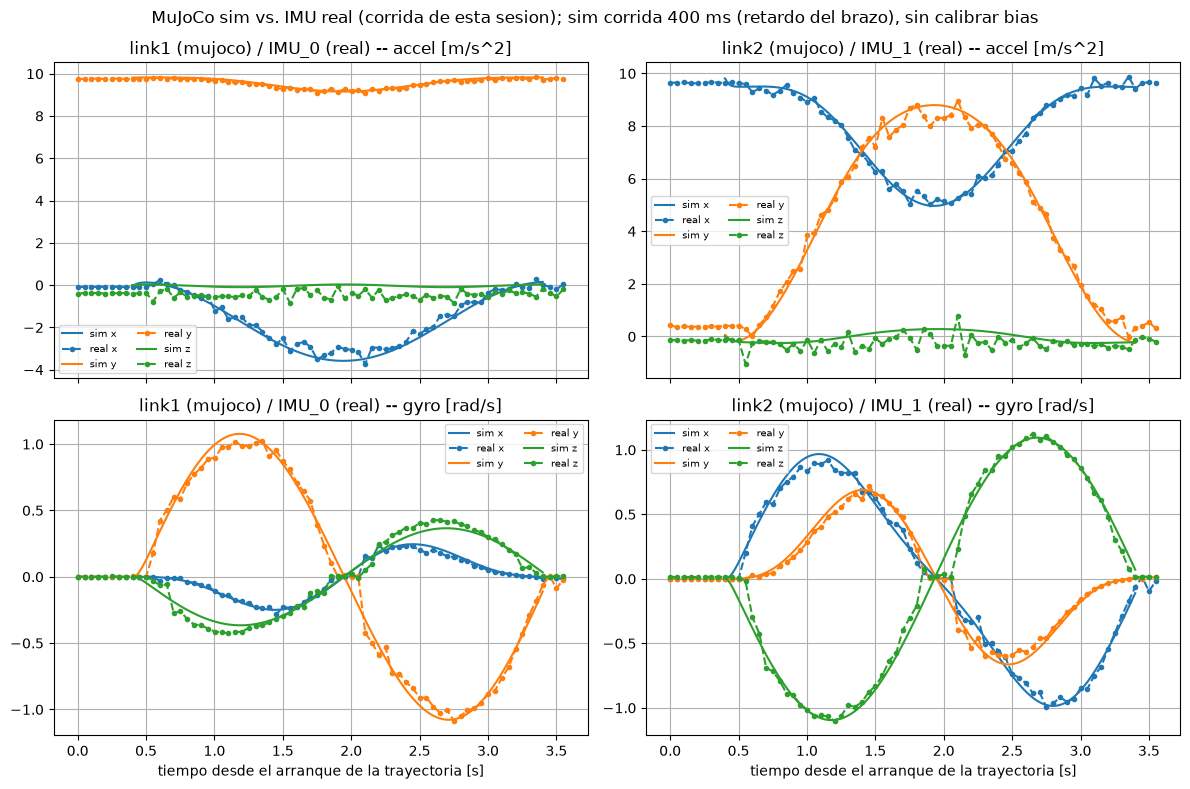

retardo brazo real vs. MuJoCo (gyro): 400 ms
RMS real - sim por eje (x, y, z), sin calibrar:
  link1 / IMU_0: acc [0.262 0.066 0.461] m/s^2   gyro [0.023 0.066 0.05 ] rad/s
  link2 / IMU_1: acc [0.181 0.318 0.355] m/s^2   gyro [0.056 0.054 0.082] rad/s


In [50]:
# ===========================================================================
# Sim (MuJoCo) vs. IMU real, en el marco del site y con el retardo alineado.
# ===========================================================================
# Los datos reales pasan por `imu_decoder`: cableado (IMU_0 -> link1,
# IMU_1 -> link2) y ejes (IMU_AXIS_MAPS) de la celda de sensores. Si esa
# celda cambia, este grafico cambia con ella, tambien para logs viejos, porque
# el CSV se guarda crudo.
#
# t = 0 es `t0_real`, el instante en que `run_trajectory` empezo a mandar --
# el mismo origen que `t` de la simulacion.
#
# RETARDO. El brazo real va ~0.4 s atrasado respecto de MuJoCo (medido en dos
# corridas: 390-400 ms; la sim misma atrasa 20-45 ms a la consigna). Sin
# alinearlo, las curvas parecen no coincidir aunque los ejes esten bien. Se
# estima con `estimate_lag` sobre los 6 canales de gyro -- ya en el mismo marco,
# asi que se comparan canal a canal -- y la sim se dibuja corrida ese tiempo.
# Es un retardo de TRANSPORTE del brazo (firmware sin `set_fresh_mode`, cola de
# setpoints), no de las IMUs: no se corrige en los datos, solo en el grafico.
#
# Lo que sigue sin corregir es bias/escala -- eso es la calibracion.
#
# Si esta sesion no corrio la celda del robot, se grafica el ultimo CSV crudo
# guardado, releido y decodificado con `ReplaySensor` -- sin hardware.

imu_t = imu_z = None
mlog_traj = globals().get("mlog_traj")     # None si la celda del robot no corrio
if mlog_traj is not None and mlog_traj.count("imu") > 0:
    imu_t_abs, imu_z, _ = mlog_traj.to_arrays("imu")
    imu_t = imu_t_abs - t0_real
    fuente = "corrida de esta sesion"
elif IMU_CSV_PATH.is_file():
    replay = ReplaySensor.from_legacy_imu_csv(IMU_CSV_PATH, imu_decoder, rows=IMU_ROWS,
                                              R=IMU_R, name="imu")
    _ms = replay.drain()
    imu_t = np.array([m.timestamp for m in _ms])
    imu_z = np.stack([m.z for m in _ms]) if _ms else np.empty((0, len(IMU_ROWS)))
    fuente = f"releido de {IMU_CSV_PATH.name}"

if imu_t is None or len(imu_t) == 0:
    print("No hay datos de IMU real para graficar (RUN_ROBOT_WITH_IMU=False y "
          f"no existe {IMU_CSV_PATH.name}).")
else:
    col = {name: imu_decoder.indices_of([name]) for name in IMU_LAYOUT}
    chip = {name: keys[0].split(".")[0] for name, keys in IMU_LAYOUT.items()}

    gyro_sim = np.hstack([link1_gyro_history, link2_gyro_history])
    gyro_real = imu_z[:, np.r_[col["link1_gyro"], col["link2_gyro"]]]
    lag_imu = estimate_lag(t, gyro_sim, imu_t, gyro_real)
    if not np.isfinite(lag_imu):
        lag_imu = 0.0
    t_sim_plot = t + lag_imu

    panels = [
        ("link1", link1_acc_history, link1_gyro_history),
        ("link2", link2_acc_history, link2_gyro_history),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    rms_rows = []
    for c, (link, sim_acc, sim_gyro) in enumerate(panels):
        ax_acc, ax_gyro = axes[0, c], axes[1, c]
        real_acc = imu_z[:, col[f"{link}_acc"]]
        real_gyro = imu_z[:, col[f"{link}_gyro"]]
        for k, axis_name in enumerate("xyz"):
            color = f"C{k}"
            ax_acc.plot(t_sim_plot, sim_acc[:, k], color=color, label=f"sim {axis_name}")
            ax_acc.plot(imu_t, real_acc[:, k], "o--", color=color, ms=3, label=f"real {axis_name}")
            ax_gyro.plot(t_sim_plot, sim_gyro[:, k], color=color, label=f"sim {axis_name}")
            ax_gyro.plot(imu_t, real_gyro[:, k], "o--", color=color, ms=3, label=f"real {axis_name}")
        inside = (imu_t >= t_sim_plot[0]) & (imu_t <= t_sim_plot[-1])
        interp = lambda X: np.column_stack([np.interp(imu_t[inside], t_sim_plot, X[:, k])
                                            for k in range(3)])
        rms_rows.append((link, chip[f"{link}_acc"],
                         np.sqrt(((real_acc[inside] - interp(sim_acc)) ** 2).mean(axis=0)),
                         np.sqrt(((real_gyro[inside] - interp(sim_gyro)) ** 2).mean(axis=0))))
        ax_acc.set_title(f"{link} (mujoco) / {chip[f'{link}_acc']} (real) -- accel [m/s^2]")
        ax_gyro.set_title(f"{link} (mujoco) / {chip[f'{link}_gyro']} (real) -- gyro [rad/s]")
        ax_gyro.set_xlabel("tiempo desde el arranque de la trayectoria [s]")
        for ax in (ax_acc, ax_gyro):
            ax.legend(fontsize=7, ncols=2)
            ax.grid(True)
    fig.suptitle(f"MuJoCo sim vs. IMU real ({fuente}); sim corrida {lag_imu * 1e3:.0f} ms "
                 f"(retardo del brazo), sin calibrar bias")
    fig.tight_layout()
    plt.show()

    print(f"retardo brazo real vs. MuJoCo (gyro): {lag_imu * 1e3:.0f} ms")
    print("RMS real - sim por eje (x, y, z), sin calibrar:")
    for link, chip_name, e_acc, e_gyro in rms_rows:
        print(f"  {link} / {chip_name}: acc {np.round(e_acc, 3)} m/s^2   gyro {np.round(e_gyro, 3)} rad/s")

### EKF ciego sobre el log real de las IMUs: posicion del efector con propagacion de error

Corre `erp.estimators.EKF` sobre `imu_t` / `imu_z` (la celda de arriba: la
corrida de esta sesion, o el CSV crudo releido) y grafica **una sola cosa**: la
posicion del site `efector` en el marco mundo, con la banda de ±2σ que sale de
propagar la covarianza completa del estado, `Σ_p = H P Hᵀ`.

- **El filtro no ve la consigna.** El `EKF` del paquete es ciego a proposito: la
  consigna vive en el firmware del brazo y llega ~400 ms tarde. Para que eso sea
  sano, los servos se compilan con dinamica `integrator` (`model_blind`, igual que
  en `finger_imu_toolkit.ipynb`): la activacion queda como random walk en vez de
  tirar cada junta a 0.
- **La linea de MuJoCo NO es verdad.** Es la replica de la misma consigna, corrida
  `lag_imu`. No hay encoder del brazo real en este log, asi que la unica
  comprobacion de consistencia sobre datos reales es el NIS.
- **La escalera es real.** Entre dos muestras de la IMU (50 ms) el filtro predice
  ~25 pasos sin saber hacia donde va el brazo: la estimacion se queda y la banda
  crece; en cada update salta. Es lo que da una IMU a 20 Hz sin consigna.

In [ ]:
# ===========================================================================
# EKF ciego: modelo, estado de reposo, bucle del filtro y propagacion al efector.
# ===========================================================================
#
# MODELO CIEGO. Con los `<position>` del XML (na = 0) y ctrl = 0, el servo tira
# cada junta hacia 0: el filtro "sabria" que el brazo vuelve a home. Con
# `integrator` cada servo gana un estado de activacion (el setpoint efectivo)
# que con ctrl = 0 se queda quieto, y Q lo vuelve random walk.
# Estado: x = [qpos (4), qvel (4), act (3)] = 11. qpos[3] es `act`, el
# paralelogramo pasivo: esta en el estado porque MuJoCo lo integra, no se mide.
#
# SINTONIA. SIG_ACT_BLIND salio de correr ESTE filtro sobre la IMU SIMULADA de
# la misma trayectoria (sensor_log_sim a 20 Hz + ruido IMU_R, verdad conocida),
# 3 semillas, con el resto de Q y P0 como abajo:
#
#   sig_act [rad/paso]   NIS medio (obj 12)   NEES efector (obj 3)   cobertura 2 sigma x / y / z
#        1e-3                  95                  25 - 30            0.35 / 0.50 / 0.81   sobreconfiado
#        3e-3                  18                 3.4 - 4.3           0.78-0.92 / 0.82 / 0.97
#        5e-3               11 - 13               1.8 - 2.2           1.00 / 1.00 / 0.93-0.96   <- este
#        1e-2                2600                    3.0              1.00 / 0.90 / 0.62   se rompe
#
# Mas Q NO es mas seguro aca: a 1e-2 el NIS explota y z queda con 17 mm de RMS.
# Y es sintonia contra la simulacion, no una derivacion: el brazo real no es
# el modelo (retardo, ganancias), asi que sobre datos reales lo que manda es el
# NIS que imprime la celda siguiente.

from erp.estimators import EKF
from erp.sim.mujoco import H_dyn, h_dyn, make_Q

SIG_ALPHA = 12.0        # rad/s^2 (1 sigma) por paso: perturbacion de aceleracion (DWNA, dt = 2 ms)
SIG_ACT_BLIND = 5e-3    # rad por paso: random walk de la activacion (tabla de arriba)
SIG_CM = 1e-4           # rad por paso a lo largo del modo comun (q_j, a_j): ver finger_imu_toolkit
REST_S = 0.4            # s: ventana quieta al principio del log (el brazo arranca ~0.5 s tarde)
REST_GYRO_MAX = 0.05    # rad/s: si la norma del gyro pasa esto en la ventana, NO es reposo


def compile_blind_model(xml_path):
    """El XML del brazo con los tres servos pasados a `dyntype="integrator"`.

    Con MjSpec y no editando el texto: el XML tiene un <include> y mallas con
    rutas relativas que `from_xml_string` no resuelve. Ganancias, forcerange y
    sensores quedan identicos. -> (model, data)
    """
    spec = mj.MjSpec.from_file(str(xml_path))
    for act in spec.actuators:
        act.dyntype = mj.mjtDyn.mjDYN_INTEGRATOR
    m = spec.compile()
    return m, mj.MjData(m)


def rest_state(model, data, q_cmd, warmup_steps=100):
    """[qpos, qvel] (rad, rad/s) del brazo QUIETO con la consigna q_cmd (3,) rad.

    Mismo calentamiento que la celda de simulacion, sobre el modelo de la
    PLANTA. El estado inicial tiene que ser este equilibrio y no ceros: con
    q = 0 y activacion 0 el servo no hace fuerza, la gravedad acelera el brazo y
    h(x0) da link2_acc_x = 4.1 m/s^2 contra 9.6 medido. El equilibrio hunde
    link1/link2 0.09/0.20 deg y da 9.81.
    """
    mj.mj_resetDataKeyframe(model, data, model.key("home").id)
    data.ctrl[:3] = q_cmd
    for _ in range(warmup_steps):
        mj.mj_step(model, data)
    return np.r_[data.qpos, data.qvel]


def run_imu_ekf(ekf, t_meas, Z, rows):
    """Corre el EKF sobre mediciones ya dadas, prediciendo de a un paso de MuJoCo.

    t_meas : (N,) s, relativo al arranque de la trayectoria. El filtro arranca en 0.
    Z      : (N, k) lecturas en el marco del site (m/s^2, rad/s), orden de `rows`
    rows   : (k,) filas de sensordata

    `predict` avanza model.opt.timestep = 2 ms y la IMU llega cada 50 ms, asi
    que entre dos mediciones hay ~25 predicts. Cada medicion se aplica en el
    paso mas cercano a su sello: error <= 1 ms contra 50 ms entre muestras.

    -> (T, XH, PP, NIS): tiempo [s], estado y covarianza en CADA paso -- los
       predicts, y en el mismo T el posterior de cada update, para que la banda
       muestre cuanto crece entre muestras -- y el NIS de cada medicion.
    """
    dt = ekf.model.opt.timestep
    z_full = np.zeros(ekf.model.nsensordata)
    k_now = 0
    T, XH, PP, NIS = [0.0], [ekf.x.copy()], [ekf.P.copy()], []
    for tk, zk in zip(t_meas, Z):
        while k_now < int(round(tk / dt)):
            ekf.predict()
            k_now += 1
            T.append(k_now * dt); XH.append(ekf.x.copy()); PP.append(ekf.P.copy())
        z_full[rows] = zk
        _, nis = ekf.update(z_full, rows)
        NIS.append(nis)
        T.append(k_now * dt); XH.append(ekf.x.copy()); PP.append(ekf.P.copy())
    return np.array(T), np.array(XH), np.array(PP), np.array(NIS)


def site_position_cov(XH, PP, model, data, rows):
    """Posicion de un sensor `framepos` y su covarianza, propagada desde el estado.

    p = h(x)[rows],   Sigma_p = H P H^T   con   H = dh/dx [rows]   (3 x nx)

    Covarianza COMPLETA, no sqrt(diag(P)) junta por junta: el efector depende de
    las tres juntas a la vez y las correlaciones que el filtro tiene entre ellas
    cambian la banda. H es la misma diferencia finita que usa el filtro; su
    bloque de q coincide con mj_jacSite a 3e-8.

    -> p (N, 3) m, marco mundo;  C (N, 3, 3) m^2
    """
    u = np.zeros(model.nu)
    p = np.empty((len(XH), 3))
    C = np.empty((len(XH), 3, 3))
    for i, (x, P) in enumerate(zip(XH, PP)):
        p[i] = h_dyn(x, u, model, data)[rows]
        H = H_dyn(x, u, model, data)[rows]
        C[i] = H @ P @ H.T
    return p, C

In [ ]:
# ===========================================================================
# Corrida del EKF sobre el log real (imu_t, imu_z de la celda "Sim vs. IMU real").
# ===========================================================================
#
# BIAS DE REPOSO. En los primeros REST_S el brazo esta quieto, asi que lo que
# difiere de h(x_rest) ahi es bias + montaje: en el log del 16/9, link1_acc_z
# -0.38 m/s^2, link2_acc_y +0.32, link2_gyro_z +0.015 rad/s -- entre 3 y 8 sigma
# de IMU_R, constantes. Con el brazo en movimiento, el NIS mediano da 114 sin
# restarlo y 29 restado (objetivo 12: sigue ~2.4x sobreconfiado). Vale
# SOLO para esta pose (una inclinacion de montaje no es un offset aditivo cuando
# el link gira): la calibracion de verdad es `calibrate()` con `expected_rest`.
# El NIS dentro de la ventana sale ~0.2 por construccion y NO entra al resumen.

if globals().get("imu_t") is None or len(imu_t) == 0:
    raise RuntimeError("No hay log de IMU: corre primero la celda 'Sim vs. IMU real'.")

model_blind, data_blind = compile_blind_model(model_path)
assert model_blind.nsensordata == model.nsensordata, "el bloque <sensor> tiene que ser el mismo"
EF_ROWS = rows_of(model_blind, "efector_pos")

# activacion = la consigna en reposo: es el setpoint que el servo esta sosteniendo
x_rest = np.r_[rest_state(model, data, q_target[0]), q_target[0]]
h_rest = h_dyn(x_rest, np.zeros(model_blind.nu), model_blind, data_blind)[IMU_ROWS]

# La guarda puede dispararse: con REST_S = 0.6 la ventana ya agarra el arranque.
rest = imu_t < REST_S
gyro_cols = imu_decoder.indices_of(["link1_gyro", "link2_gyro"])
rest_gyro = np.linalg.norm(imu_z[rest][:, gyro_cols], axis=1).max() if rest.any() else np.inf
if rest.sum() < 3 or rest_gyro > REST_GYRO_MAX:
    raise ValueError(f"La ventana de reposo [0, {REST_S}) s no esta quieta: {rest.sum()} muestras, "
                     f"norma de gyro max {rest_gyro:.3f} rad/s (limite {REST_GYRO_MAX}). Acorta REST_S.")
imu_bias = imu_z[rest].mean(axis=0) - h_rest

R_full = make_R(model_blind, SIG_ACC, SIG_GYRO)
Q_blind = make_Q(model_blind, SIG_ALPHA, SIG_ACT_BLIND, SIG_CM)
P0 = np.diag([np.deg2rad(1.0) ** 2] * 4      # q, rad^2: el brazo llego a home con <= 0.8 deg de error
             + [np.deg2rad(5.0) ** 2] * 4    # v, (rad/s)^2: quieto, holgado
             + [np.deg2rad(0.5) ** 2] * 3)   # act, rad^2: chico A PROPOSITO. Grande satura el servo
                                             # del modelo y la activacion deja de ser observable
                                             # (finger_imu_toolkit, p0_act_deg).

ekf = EKF(x_rest, P0, Q_blind, R_full, model_blind, data_blind)
_t_run = time.perf_counter()
T_ekf, XH_ekf, PP_ekf, NIS_ekf = run_imu_ekf(ekf, imu_t, imu_z - imu_bias, IMU_ROWS)
p_ef, C_ef = site_position_cov(XH_ekf, PP_ekf, model_blind, data_blind, EF_ROWS)
sig_ef = np.sqrt(np.einsum("nii->ni", C_ef))      # (N, 3) m, 1 sigma por eje del mundo
_t_run = time.perf_counter() - _t_run

moving = imu_t >= REST_S
print(f"EKF ciego: {len(imu_t)} mediciones, {len(T_ekf)} pasos en {T_ekf[-1]:.2f} s, "
      f"corrio en {_t_run:.1f} s")
print("bias de reposo restado (link1_acc, link2_acc, link1_gyro, link2_gyro):")
print("  ", np.round(imu_bias, 3))
print(f"NIS con el brazo en movimiento ({moving.sum()} muestras, objetivo {len(IMU_ROWS)}): "
      f"media {NIS_ekf[moving].mean():.1f}, mediana {np.median(NIS_ekf[moving]):.1f}, "
      f"max {NIS_ekf[moving].max():.0f}")
print(f"sigma del efector [mm] x/y/z: mediana {np.round(np.median(sig_ef, axis=0) * 1e3, 1)}, "
      f"max {np.round(sig_ef.max(axis=0) * 1e3, 1)}")
print(f"juntas al final [deg] (rot, link1, link2): {np.round(np.rad2deg(XH_ekf[-1, :3]), 2)}")

In [ ]:
# ===========================================================================
# Grafico: posicion del efector estimada, banda de 2 sigma, y MuJoCo corrido.
# ===========================================================================
#
# Un panel por eje del MUNDO, en mm. La banda es 2 * sqrt(diag(H P H^T)): la
# diagonal de la covarianza YA propagada, no una propagacion por junta.
# MuJoCo va punteado y corrido `lag_imu` (retardo del brazo medido en la celda
# de arriba). Es la consigna replicada, NO verdad: donde se separa de la banda
# puede ser el filtro o puede ser que el brazo real no hizo lo que MuJoCo.
# Antes de t = lag_imu y al final se extiende quieto en sus extremos.

_lag = globals().get("lag_imu", 0.0)
ef_sim = sensor_log_sim[:, rows_of(model, "efector_pos")]        # (n, 3) m, marco mundo
ref_ef = np.column_stack([np.interp(T_ekf - _lag, t, ef_sim[:, k]) for k in range(3)])
inside = np.abs(ref_ef - p_ef) <= 2 * sig_ef

fig, axes = plt.subplots(3, 1, figsize=(9.5, 8.0), sharex=True, facecolor=SURFACE)
for k, ax in enumerate(axes):
    _style(ax)
    ax.fill_between(T_ekf, (p_ef[:, k] - 2 * sig_ef[:, k]) * 1e3,
                    (p_ef[:, k] + 2 * sig_ef[:, k]) * 1e3,
                    color=C_REAL, alpha=0.22, lw=0, zorder=2, label="EKF ±2σ")
    ax.plot(T_ekf, p_ef[:, k] * 1e3, color=C_REAL, lw=2.0, zorder=3,
            label="EKF (IMU real)")
    ax.plot(T_ekf, ref_ef[:, k] * 1e3, color=C_SIM, lw=2.0, ls="--", zorder=4,
            label=f"MuJoCo, corrido {_lag * 1e3:.0f} ms (referencia)")
    ax.set_ylabel(f"efector {'xyz'[k]}\n[mm]", color=INK2, fontsize=10)
    ax.text(0.99, 0.04, f"MuJoCo dentro de ±2σ: {inside[:, k].mean():.0%}",
            transform=ax.transAxes, ha="right", va="bottom", color=MUTED, fontsize=9)
axes[-1].set_xlabel("Tiempo desde el arranque de la trayectoria [s]", color=INK2, fontsize=10)
_header(fig, axes, "Posicion del efector: EKF ciego sobre las IMUs reales, con propagacion "
                   "de covarianza", ncols=3)
plt.show()